# **Project Name**    - **Shark_Tank_India_EDA_Visualization**

* **Project Type:** Exploratory Data Analysis (EDA)
* **Project Nature:** Individual Contribution
* **Author:** Tajveer Singh


# **Business Context and Problem Overview**

*Shark Tank India* has become one of India's most popular entrepreneurship shows, showcasing innovative startups seeking investments from experienced investors. This project leverages Exploratory Data Analysis (EDA) and data visualization techniques to uncover valuable insights from the Shark Tank India dataset.

### Key Questions Explored

* Which startups turned down the sharks' offers?
* What was the maximum number of sharks involved in a deal?
* How much did each shark invest overall?
* What do the investment portfolios of different sharks look like?
* Which startups received their exact requested valuation?
* Which companies were pre-revenue at the time of pitching?

### Project Workflow

1. Import and set up the required libraries.
2. Load and understand the dataset.
3. Explore the data to discover meaningful insights.
4. Visualize trends and patterns using charts and graphs.


## Connect With Me

- GitHub: https://github.com/tajveersingh1
- LinkedIn: www.linkedin.com/in/tajveer-singh-133939202

# Let's dive into the project.

#  Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from babel.numbers import format_currency

# Loading Dataset

In [2]:
shark_tank = pd.read_csv('Shark Tank India.csv')

In [3]:
shark_tank.head(10)

,Season Number,Startup Name,Season Start,Season End,Episode Number,Episode Title,Anchor,Pitch Number,Industry,Business Description,...,Guest Name,Ashneer Present,Namita Present,Anupam Present,Vineeta Present,Aman Present,Peyush Present,Ghazal Present,Amit Present,Guest Present
0,1,BluePineFoods,20-Dec-21,04-Feb-22,1,Badlegi Business Ki Tasveer,Rannvijay Singh,1,Food,Frozen Momos,...,NaN,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN
1,1,BoozScooters,20-Dec-21,04-Feb-22,1,Badlegi Business Ki Tasveer,Rannvijay Singh,2,Vehicles/Electrical Vehicles,Renting e-bike for mobility in private spaces,...,NaN,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN
2,1,HeartUpMySleeves,20-Dec-21,04-Feb-22,1,Badlegi Business Ki Tasveer,Rannvijay Singh,3,Beauty/Fashion,Detachable Sleeves,...,NaN,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN
3,1,TagzFoods,20-Dec-21,04-Feb-22,2,"Insaan, Ideas Aur Sapne",Rannvijay Singh,4,Food,Healthy Potato Chips Snacks,...,NaN,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN
4,1,HeadAndHeart,20-Dec-21,04-Feb-22,2,"Insaan, Ideas Aur Sapne",Rannvijay Singh,5,Education,Brain Development Course,...,NaN,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN
5,1,Agritourism,20-Dec-21,04-Feb-22,2,"Insaan, Ideas Aur Sapne",Rannvijay Singh,6,Agriculture,Tourism,...,NaN,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN
6,1,qZenseLabs,20-Dec-21,04-Feb-22,3,Aam Aadmi Ke Business Ideas,Rannvijay Singh,7,Food,Food Freshness Detector,...,NaN,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN
7,1,Peeschute,20-Dec-21,04-Feb-22,3,Aam Aadmi Ke Business Ideas,Rannvijay Singh,8,Beauty/Fashion,Disposable Urine Bag,...,NaN,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN
8,1,NOCD,20-Dec-21,04-Feb-22,3,Aam Aadmi Ke Business Ideas,Rannvijay Singh,9,Food,Energy Drink,...,NaN,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN
9,1,CosIQ,20-Dec-21,04-Feb-22,4,Entrepreneurship Ki Wave,Rannvijay Singh,10,Beauty/Fashion,Intelligent Skincare,...,NaN,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN


In [4]:
shark_tank.tail(10)

,Season Number,Startup Name,Season Start,Season End,Episode Number,Episode Title,Anchor,Pitch Number,Industry,Business Description,...,Guest Name,Ashneer Present,Namita Present,Anupam Present,Vineeta Present,Aman Present,Peyush Present,Ghazal Present,Amit Present,Guest Present
311,2,Sahayatha,02-Jan-23,10-Mar-23,49,Businesses Adding Value To Society,Rahul Dua,312,Medical/Health,smart wheelchair with an assistive cleansing d...,...,NaN,NaN,1.0,1.0,1.0,1.0,1.0,NaN,1.0,NaN
312,2,WickedGud,02-Jan-23,10-Mar-23,49,Businesses Adding Value To Society,Rahul Dua,313,Food,High Protein & Fiber Gluten Free Vegan food,...,NaN,NaN,1.0,1.0,1.0,1.0,1.0,NaN,1.0,NaN
313,2,maisha,02-Jan-23,10-Mar-23,49,Businesses Adding Value To Society,Rahul Dua,314,Beauty/Fashion,Handmade Cotton & Jacquard Bags,...,NaN,NaN,1.0,1.0,1.0,1.0,1.0,NaN,1.0,NaN
314,2,NishHair,02-Jan-23,10-Mar-23,50,Season Finale With The Sharks,Rahul Dua,315,Beauty/Fashion,100% Human Hair Extensions,...,NaN,NaN,1.0,1.0,1.0,1.0,1.0,NaN,1.0,NaN
315,2,MYBYK,02-Jan-23,10-Mar-23,50,Season Finale With The Sharks,Rahul Dua,316,Vehicles/Electrical Vehicles,IoT-enabled bikes,...,NaN,NaN,1.0,1.0,1.0,1.0,1.0,NaN,1.0,NaN
316,2,GODESi,02-Jan-23,10-Mar-23,51,Gateway To Shark Tank India,Rahul Dua,317,Food,Handmade lollipops,...,NaN,NaN,1.0,NaN,1.0,1.0,NaN,NaN,1.0,1.0
317,2,TAC,02-Jan-23,10-Mar-23,51,Gateway To Shark Tank India,Rahul Dua,318,Beauty/Fashion,"ayurveda co for glowing skin, makeup & open pores",...,Vikas,NaN,1.0,NaN,1.0,1.0,NaN,NaN,1.0,1.0
318,2,Naara-Aaba,02-Jan-23,10-Mar-23,51,Gateway To Shark Tank India,Rahul Dua,319,Liquor/Beverages,pears and plum wine,...,Vikas,NaN,1.0,NaN,1.0,1.0,NaN,NaN,1.0,1.0
319,2,StyloBug,02-Jan-23,10-Mar-23,51,Gateway To Shark Tank India,Rahul Dua,320,Beauty/Fashion,Girls Dresses Online,...,NaN,NaN,1.0,NaN,1.0,1.0,NaN,NaN,1.0,1.0
320,2,ZenOnco,02-Jan-23,10-Mar-23,0,Unseen,Rahul Dua,321,Medical/Health,saving lives from cancer,...,NaN,NaN,1.0,NaN,1.0,1.0,NaN,NaN,1.0,1.0


In [5]:
shark_tank.columns

Index(['Season Number', 'Startup Name', 'Season Start', 'Season End',
       'Episode Number', 'Episode Title', 'Anchor', 'Pitch Number', 'Industry',
       'Business Description', 'Company Website', 'Number of Presenters',
       'Male Presenters', 'Female Presenters', 'Transgender Presenters',
       'Couple Presenters', 'Pitchers Average Age', 'Started in',
       'Pitchers City', 'Pitchers State', 'Yearly Revenue', 'Monthly Sales',
       'Gross Margin', 'Net Margin', 'Original Ask Amount',
       'Original Offered Equity', 'Valuation Requested', 'Received Offer',
       'Accepted Offer', 'Total Deal Amount', 'Total Deal Equity',
       'Total Deal Debt', 'Debt Interest', 'Deal Valuation',
       'Number of sharks in deal', 'Deal has conditions', 'Has Patents',
       'Ashneer Investment Amount', 'Ashneer Investment Equity',
       'Ashneer Debt Amount', 'Namita Investment Amount',
       'Namita Investment Equity', 'Namita Debt Amount',
       'Anupam Investment Amount', 'Anupam I

# Dataset Information

In [6]:
shark_tank.info()     #Dataset Overview: Examining Features and Data Types


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 321 entries, 0 to 320
Data columns (total 74 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Season Number              321 non-null    int64  
 1   Startup Name               321 non-null    object 
 2   Season Start               321 non-null    object 
 3   Season End                 321 non-null    object 
 4   Episode Number             321 non-null    int64  
 5   Episode Title              321 non-null    object 
 6   Anchor                     321 non-null    object 
 7   Pitch Number               321 non-null    int64  
 8   Industry                   321 non-null    object 
 9   Business Description       321 non-null    object 
 10  Company Website            310 non-null    object 
 11  Number of Presenters       321 non-null    int64  
 12  Male Presenters            282 non-null    float64
 13  Female Presenters          150 non-null    float64

In [7]:
shark_tank.describe()     #Statistical Summary of Numerical Features


,Season Number,Episode Number,Pitch Number,Number of Presenters,Male Presenters,Female Presenters,Transgender Presenters,Couple Presenters,Started in,Yearly Revenue,...,Guest Debt Amount,Ashneer Present,Namita Present,Anupam Present,Vineeta Present,Aman Present,Peyush Present,Ghazal Present,Amit Present,Guest Present
count,321.000000,321.000000,321.000000,321.000000,282.000000,150.000000,3.0,316.000000,184.000000,135.000000,...,2.000000,99.0,276.0,282.0,187.0,268.0,233.0,26.0,83.0,5.0
mean,1.526480,21.482866,161.000000,2.077882,1.719858,1.193333,1.0,0.186709,2018.472826,353.303704,...,23.500000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
std,0.500078,14.702695,92.808944,0.846044,0.866269,0.428775,0.0,0.390296,2.495750,915.969002,...,15.556349,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.0,0.000000,2005.000000,-1.000000,...,12.500000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
25%,1.000000,9.000000,81.000000,2.000000,1.000000,1.000000,1.0,0.000000,2017.000000,0.000000,...,18.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
50%,2.000000,21.000000,161.000000,2.000000,2.000000,1.000000,1.0,0.000000,2019.000000,100.000000,...,23.500000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
75%,2.000000,33.000000,241.000000,2.000000,2.000000,1.000000,1.0,0.000000,2020.000000,245.000000,...,29.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
max,2.000000,51.000000,321.000000,6.000000,6.000000,3.000000,1.0,1.000000,2022.000000,7200.000000,...,34.500000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [8]:
# Analyzing Dataset Size: Rows and Columns
print( shark_tank.shape)
print("Number of Rows:", shark_tank.shape[0])
print("Number of Columns:", shark_tank.shape[1])

(321, 74)
Number of Rows: 321
Number of Columns: 74


In [9]:
# Dataset Duplicate Value Count
duplicate_values=len(shark_tank[shark_tank.duplicated()])

print("Number of duplicate values:", duplicate_values)

Number of duplicate values: 0


In [10]:
# Finding Null Values Count
shark_tank.isna().sum()

,0
Season Number,0
Startup Name,0
Season Start,0
Season End,0
Episode Number,0
...,...
Aman Present,53
Peyush Present,88
Ghazal Present,295
Amit Present,238


In [11]:
# Checking null values from high to low
shark_tank.isnull().sum().sort_values(ascending=False)

,0
Ghazal Debt Amount,321
Ashneer Debt Amount,319
Guest Name,319
Guest Debt Amount,319
Guest Investment Equity,319
...,...
Number of Presenters,0
Pitchers City,0
Pitchers State,0
Original Ask Amount,0


In [12]:
# Checking total null values
shark_tank.isnull().sum().sum()

np.int64(13126)

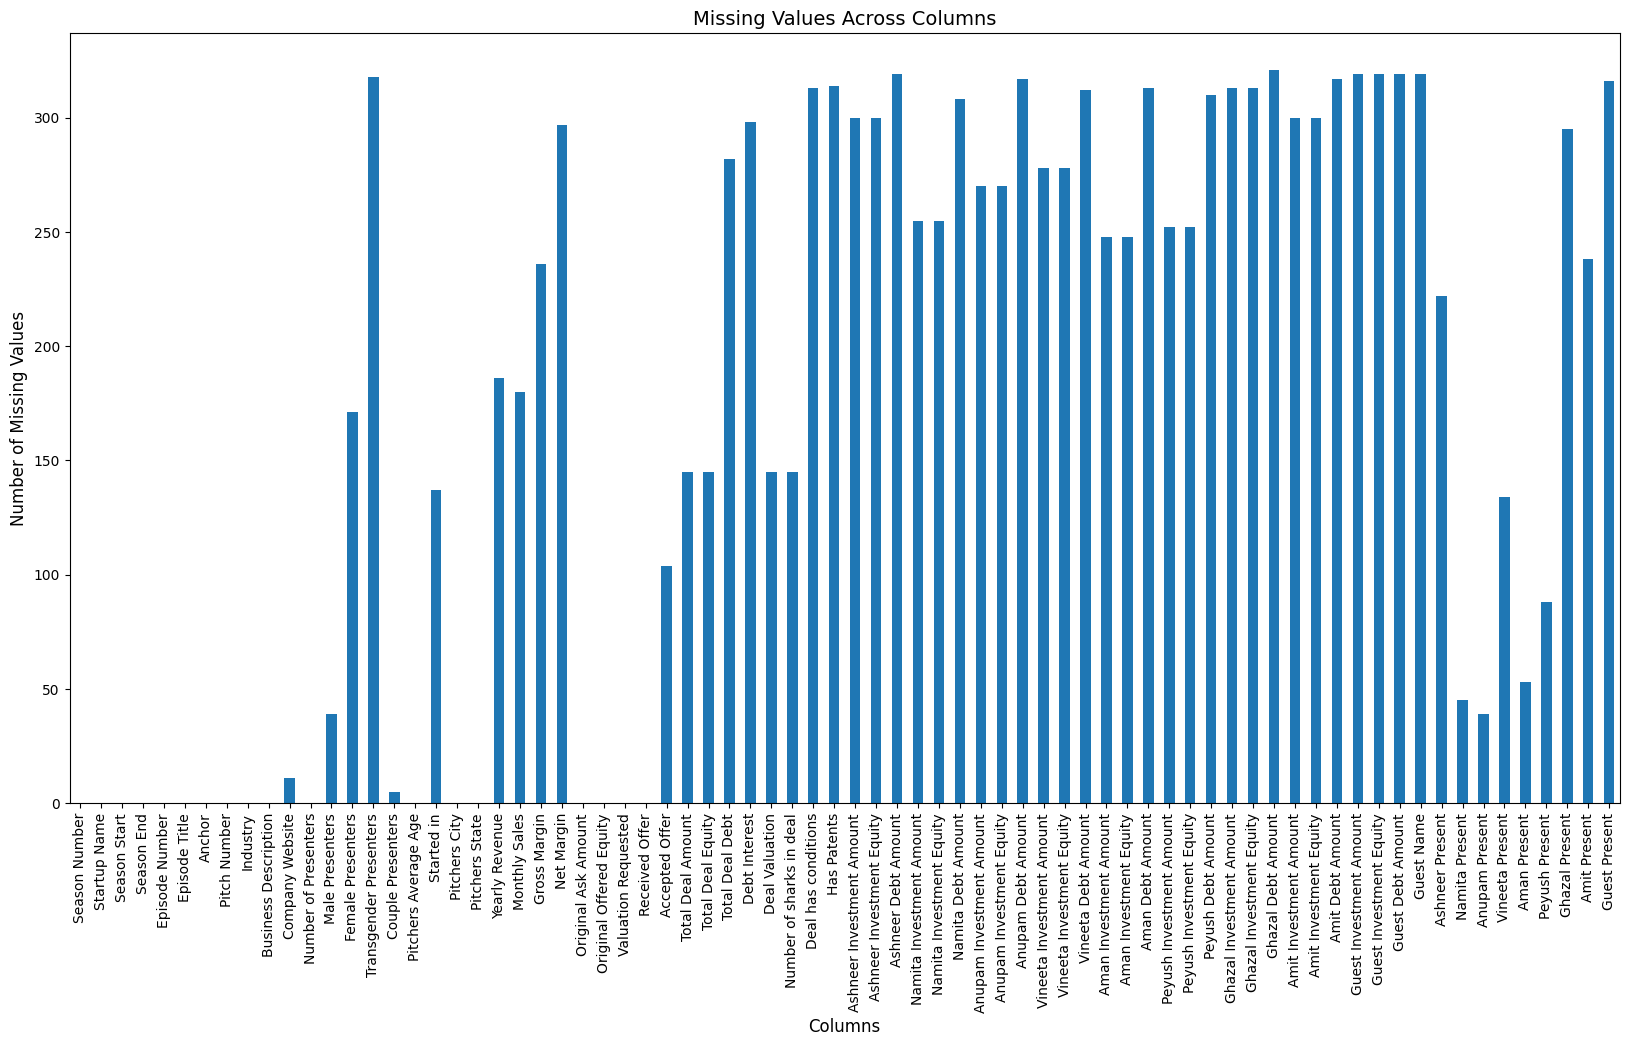

In [13]:
# Count missing values in each column
missing_values = shark_tank.isnull().sum()

# Plotting missing values as a bar chart
plt.figure(figsize=(20,10))

missing_values.plot(kind='bar')

plt.xlabel("Columns", fontsize=12)
plt.ylabel("Number of Missing Values", fontsize=12)
plt.title("Missing Values Across Columns", fontsize=14)


plt.show()

## Correlation Analysis of Numerical Variables

In [14]:
shark_tank.select_dtypes(include='number').corr().T.round(2)\
.style.background_gradient(cmap='coolwarm')

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/style.py:3807: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/style.py:3808: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax


,Season Number,Episode Number,Pitch Number,Number of Presenters,Male Presenters,Female Presenters,Transgender Presenters,Couple Presenters,Started in,Yearly Revenue,Monthly Sales,Gross Margin,Net Margin,Original Ask Amount,Original Offered Equity,Valuation Requested,Received Offer,Accepted Offer,Total Deal Amount,Total Deal Equity,Total Deal Debt,Debt Interest,Deal Valuation,Number of sharks in deal,Has Patents,Ashneer Investment Amount,Ashneer Investment Equity,Ashneer Debt Amount,Namita Investment Amount,Namita Investment Equity,Namita Debt Amount,Anupam Investment Amount,Anupam Investment Equity,Anupam Debt Amount,Vineeta Investment Amount,Vineeta Investment Equity,Vineeta Debt Amount,Aman Investment Amount,Aman Investment Equity,Aman Debt Amount,Peyush Investment Amount,Peyush Investment Equity,Peyush Debt Amount,Ghazal Investment Amount,Ghazal Investment Equity,Ghazal Debt Amount,Amit Investment Amount,Amit Investment Equity,Amit Debt Amount,Guest Investment Amount,Guest Investment Equity,Guest Debt Amount,Ashneer Present,Namita Present,Anupam Present,Vineeta Present,Aman Present,Peyush Present,Ghazal Present,Amit Present,Guest Present
Season Number,1.000000,0.390000,0.860000,0.010000,0.040000,0.070000,nan,-0.070000,0.090000,-0.030000,0.280000,0.000000,nan,-0.050000,-0.250000,0.090000,0.090000,0.190000,0.110000,-0.410000,0.150000,nan,0.270000,-0.150000,nan,nan,nan,nan,0.140000,-0.170000,0.210000,0.340000,-0.150000,0.360000,0.280000,-0.390000,-0.110000,0.170000,-0.350000,-0.260000,0.160000,-0.360000,0.480000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
Episode Number,0.390000,1.000000,0.630000,-0.000000,0.070000,0.010000,nan,-0.070000,-0.030000,0.120000,0.150000,-0.040000,-0.080000,-0.040000,-0.140000,0.070000,0.000000,0.060000,0.040000,-0.160000,-0.050000,0.290000,0.110000,0.020000,nan,-0.270000,-0.180000,1.000000,-0.090000,-0.070000,-0.290000,-0.080000,-0.190000,-0.770000,0.040000,-0.410000,-0.280000,0.080000,-0.180000,-0.270000,0.080000,-0.040000,0.190000,-0.420000,0.030000,nan,-0.050000,-0.310000,0.950000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
Pitch Number,0.860000,0.630000,1.000000,-0.000000,0.030000,-0.020000,nan,-0.070000,0.110000,0.030000,0.270000,-0.030000,-0.090000,-0.070000,-0.220000,0.090000,-0.070000,0.080000,0.100000,-0.390000,0.090000,0.310000,0.260000,-0.100000,nan,-0.260000,-0.160000,1.000000,0.060000,-0.160000,-0.120000,0.230000,-0.200000,-0.020000,0.220000,-0.490000,-0.240000,0.160000,-0.340000,-0.340000,0.170000,-0.330000,0.460000,0.100000,-0.260000,nan,-0.050000,-0.310000,0.950000,-1.000000,1.000000,-1.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan
Number of Presenters,0.010000,-0.000000,-0.000000,1.000000,0.760000,0.320000,nan,0.140000,-0.040000,-0.050000,0.040000,-0.170000,0.080000,-0.070000,-0.150000,0.040000,0.060000,-0.020000,0.080000,-0.260000,0.290000,0.270000,0.150000,0.030000,nan,-0.080000,-0.280000,nan,-0.090000,-0.110000,-0.250000,0.010000,-0.290000,nan,0.190000,-0.230000,-0.320000,0.130000,0.030000,0.490000,0.090000,-0.320000,0.500000,0.280000,-0.450000,nan,-0.290000,-0.070000,0.800000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
Male Presenters,0.040000,0.070000,0.030000,0.760000,1.000000,-0.020000,nan,-0.340000,0.000000,-0.040000,0.060000,-0.100000,-0.150000,-0.040000,-0.170000,0.040000,0.030000,0.070000,0.100000,-0.150000,0.360000,0.150000,0.210000,0.050000,nan,-0.170000,-0.170000,1.000000,0.000000,-0.170000,0.250000,-0.010000,-0.230000,0.460000,-0.080000,-0.020000,0.160000,0.240000,0.060000,0.330000,0.070000,-0.200000,0.380000,0.060000,-0.280000,nan,-0.200000,-0.370000,0.870000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
Female Presenters,0.070000,0.010000,-0.020000,0.320000,-0.020000,1.000000,nan,-0.090000,0.040000,-0.150000,-0.060000,0.080000,0.190000,-0.050000,0.010000,0.080000,0.130000,-0.100000,-0.170000,-0.000000,-0.140000,-0.340000,-0.070000,-0.150000,nan,nan,nan,nan,-0.160000,-0.140000,-0.590000,-0.070000,0.000000,nan,0.010000,-0.120000,-0.

# Exploratory Analysis and Visualization

In [15]:
shark_tank['Season Number'].value_counts()

,count
Season Number,
2,169
1,152


In [16]:
print(f"Total Seasons: {shark_tank['Season Number'].max()}")
print(f"Total Episodes: {shark_tank['Episode Number'].max()}")
print(f"Total Startups Pitched: {shark_tank['Pitch Number'].max()}")

Total Seasons: 2
Total Episodes: 51
Total Startups Pitched: 321


In [17]:
shark_tank['Season Start'].value_counts()

,count
Season Start,
02-Jan-23,169
20-Dec-21,152


In [18]:
shark_tank['Season End'].value_counts()

,count
Season End,
10-Mar-23,169
04-Feb-22,152


## Distribution of Entrepreneurs Across Cities

In [19]:
top_cities = shark_tank['Pitchers City'].value_counts()

print(top_cities)

Pitchers City
Mumbai                56
Delhi                 44
Bangalore             32
Pune                  20
Ahmedabad             19
                      ..
Gopalganj              1
Ahmedabad,Mirzapur     1
Aurangabad             1
Ziro                   1
Jodhpur                1
Name: count, Length: 79, dtype: int64


/tmp/ipykernel_18891/3102317742.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


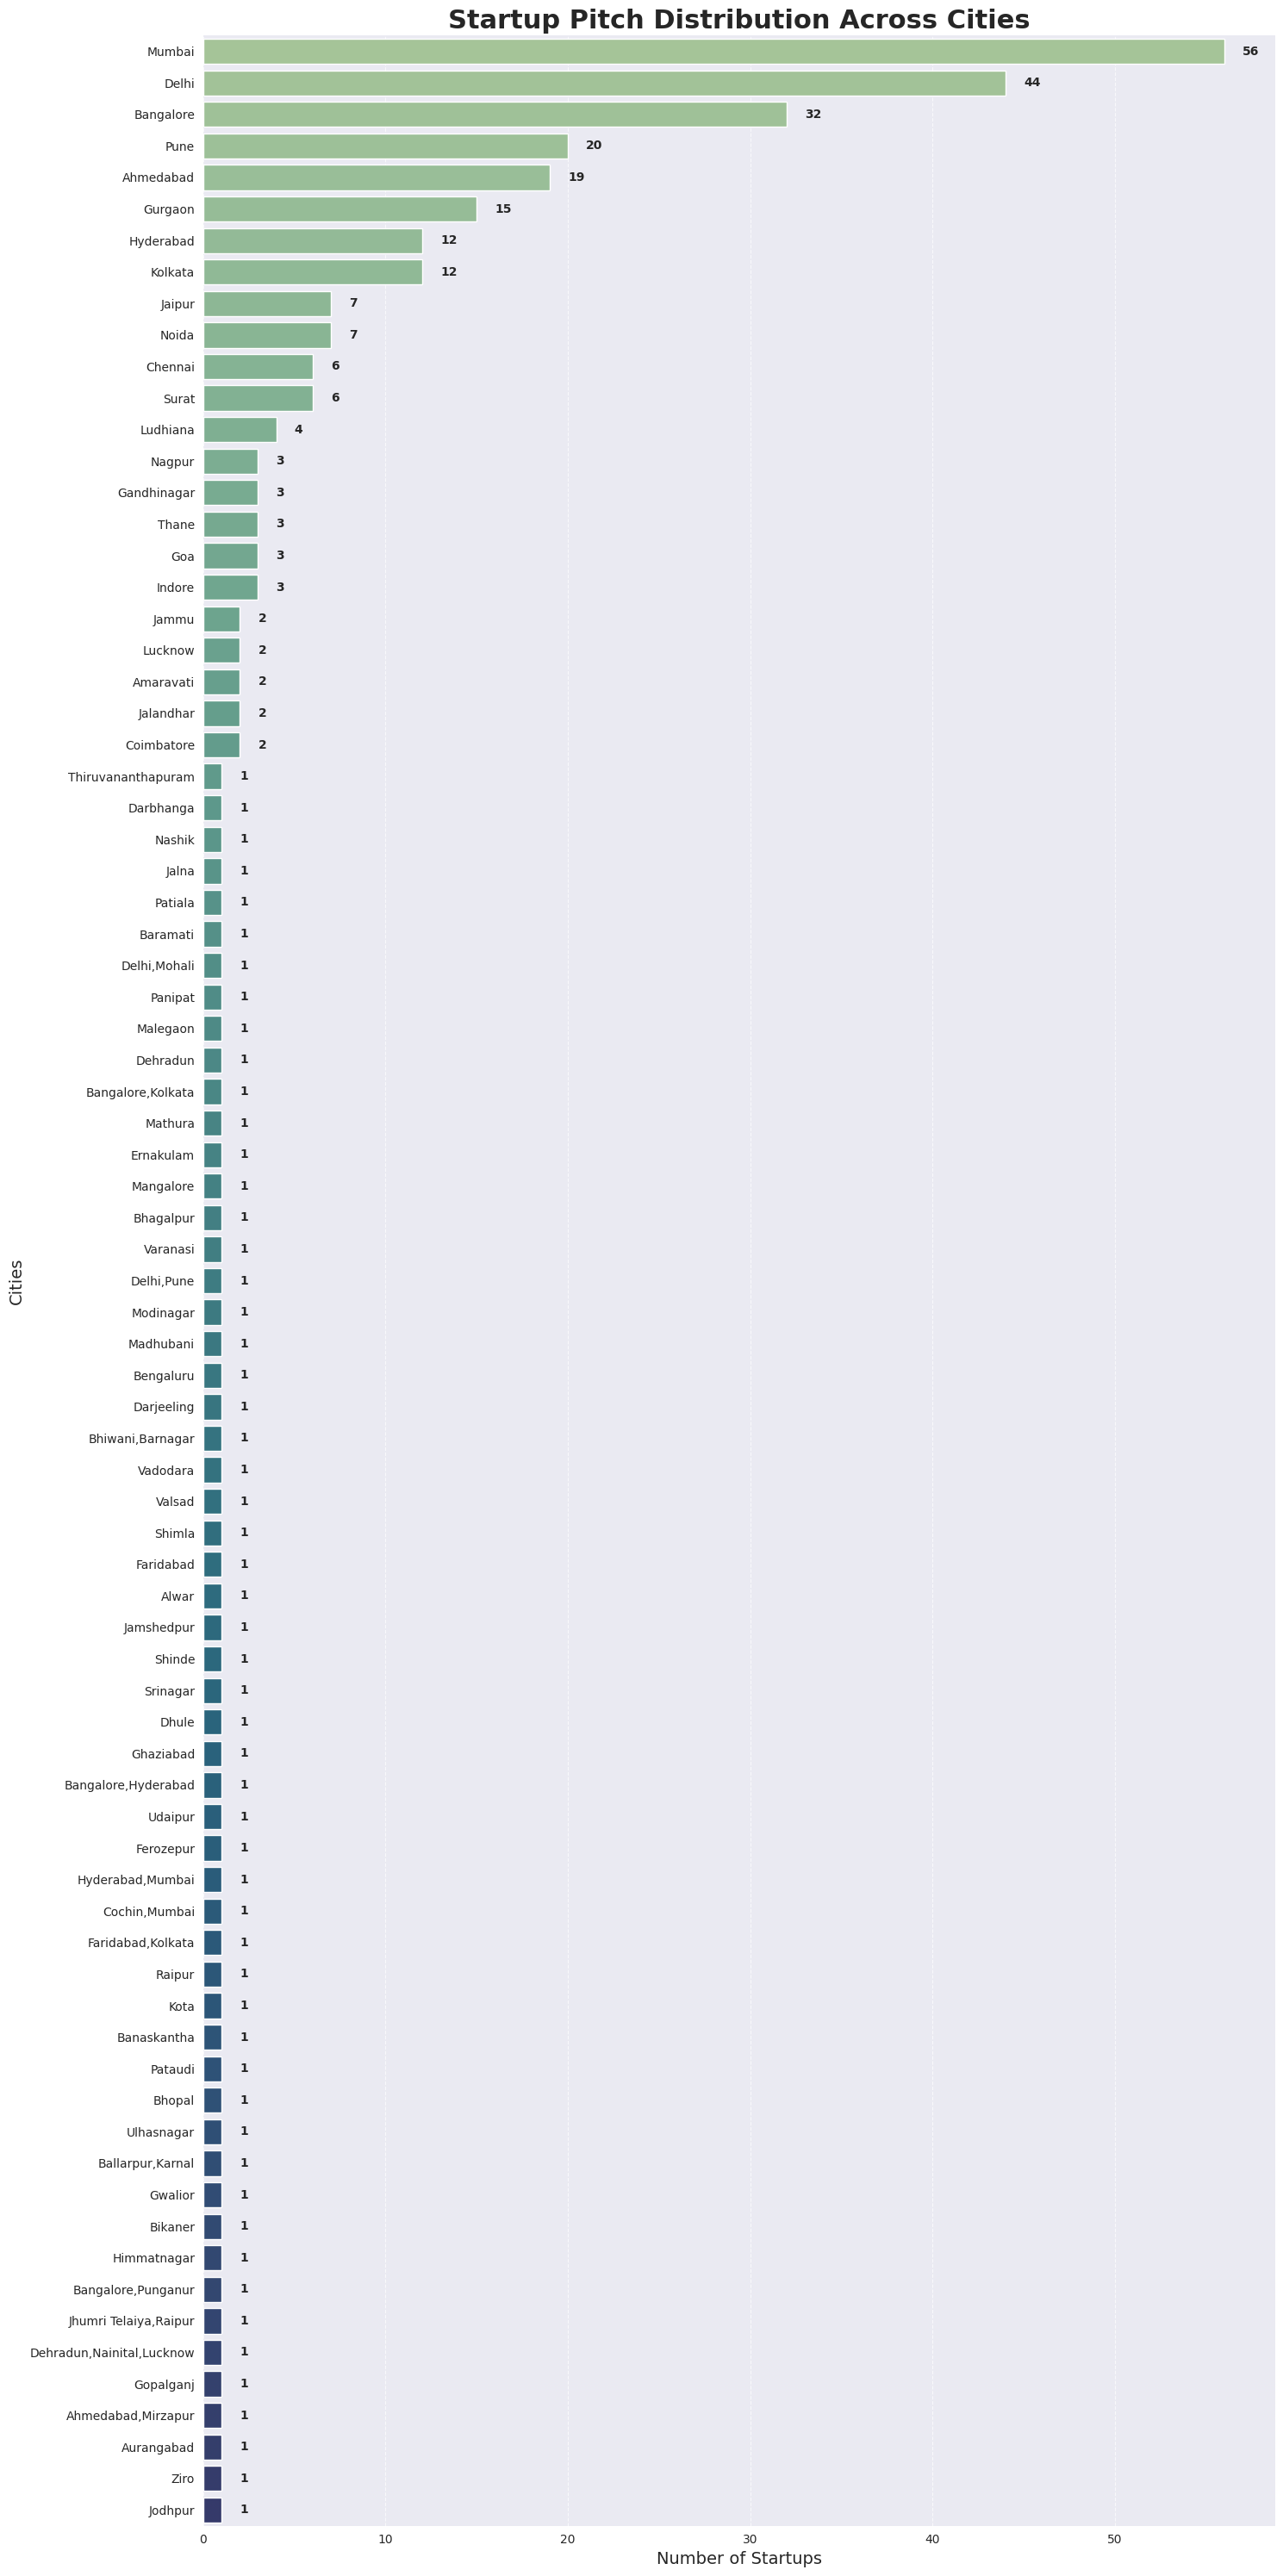

In [20]:
# Set style
sns.set_style('darkgrid')

plt.figure(figsize=(15, 30))

ax = sns.countplot(
    data=shark_tank,
    y='Pitchers City',
    order=shark_tank['Pitchers City'].value_counts().index,
    palette='crest'
)

# Add count labels at the end of each bar
for p in ax.patches:
    ax.text(
        p.get_width() + 1,
        p.get_y() + p.get_height()/2,
        f'{int(p.get_width())}',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title('Startup Pitch Distribution Across Cities',
          fontsize=22,
          fontweight='bold')

plt.xlabel('Number of Startups', fontsize=14)
plt.ylabel('Cities', fontsize=14)

plt.grid(axis='x', linestyle='--', alpha=0.7)

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

## Analyzing the Founding Years of Startups

In [21]:
startup_years = shark_tank['Started in'].value_counts()

print('startup_years',startup_years)

startup_years Started in
2019.0    38
2020.0    31
2021.0    27
2018.0    26
2017.0    22
2016.0    18
2022.0     9
2015.0     4
2014.0     4
2005.0     1
2013.0     1
2012.0     1
2006.0     1
2010.0     1
Name: count, dtype: int64


/tmp/ipykernel_18891/1220822908.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=shark_tank,x='Started in', palette="hot", order=shark_tank['Started in'].value_counts().index)


Text(0.5, 1.0, 'Startup Establishment Timeline')

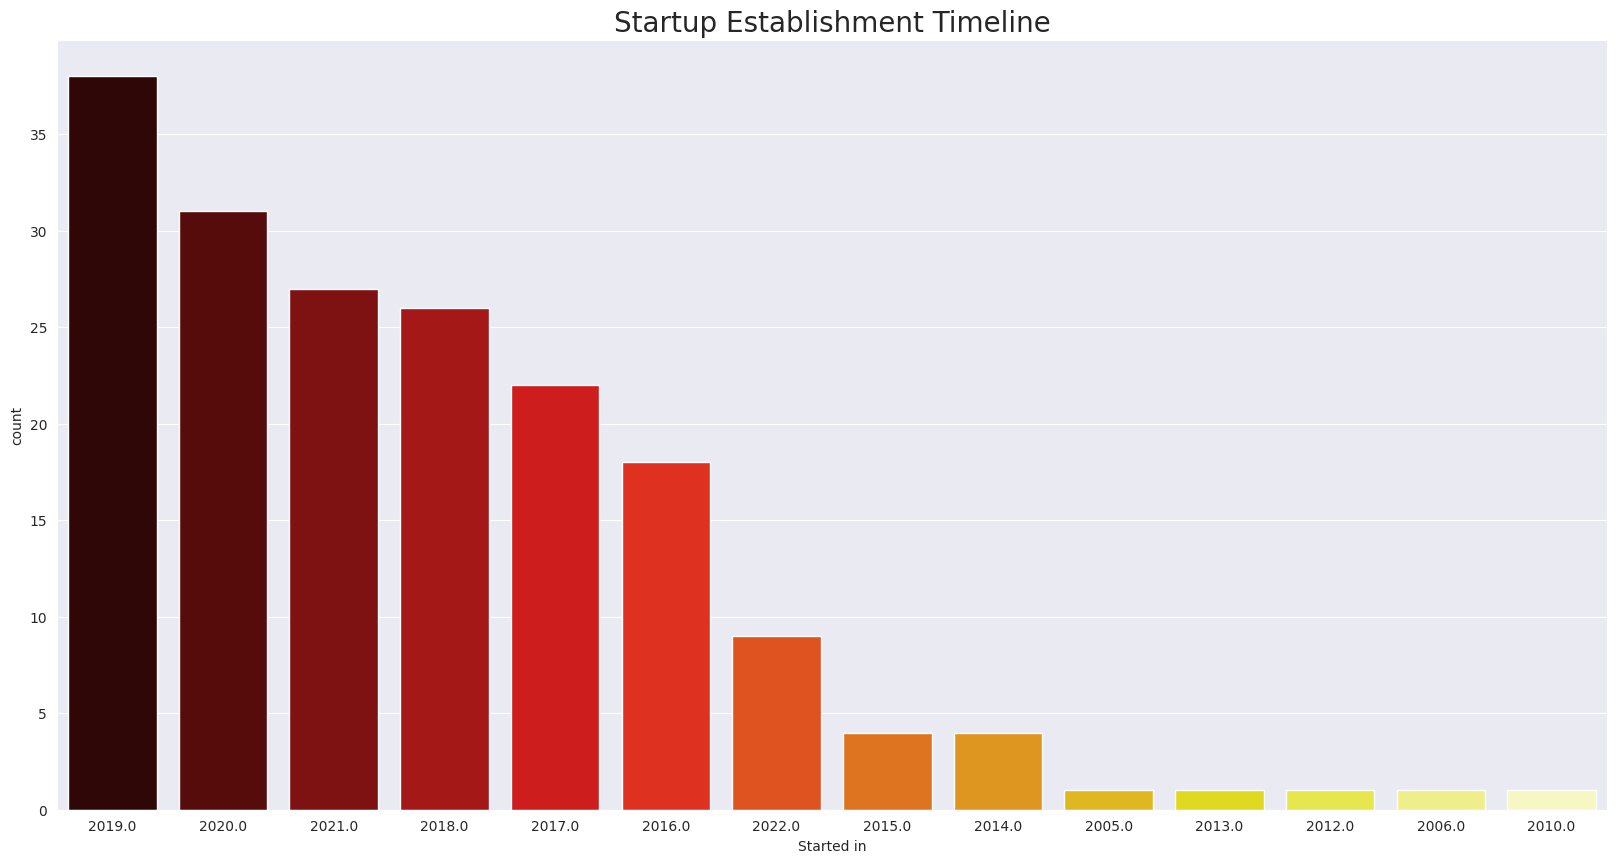

In [22]:
plt.figure(figsize=(20,10))
sns.countplot(data=shark_tank,x='Started in', palette="hot", order=shark_tank['Started in'].value_counts().index)
plt.title('Startup Establishment Timeline',size=20)

## Geographic Distribution of Pitchers Across States


In [23]:
state_counts = shark_tank['Pitchers State'].value_counts()

print(f"State-wise Distribution of {state_counts} ")

State-wise Distribution of Pitchers State
Maharashtra                  92
Delhi                        44
Karnataka                    34
Gujarat                      32
Haryana                      18
West Bengal                  13
Uttar Pradesh                13
Rajasthan                    12
Telangana                    12
Punjab                        8
Tamil Nadu                    8
Madhya Pradesh                5
Bihar                         4
Jammu & Kashmir               3
Goa                           3
Kerala                        2
Karnataka,West Bengal         1
Delhi,Punjab                  1
Uttarakhand                   1
Delhi,Maharashtra             1
Haryana,Madhya Pradesh        1
Himachal Pradesh              1
Jharkhand                     1
Karnataka,Telangana           1
Telangana,Maharashtra         1
Kerala,Maharashtra            1
Haryana,West Bengal           1
Chhattisgarh                  1
Haryana,Maharashtra           1
Karnataka,Andhra Pradesh      

/tmp/ipykernel_18891/2593854797.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


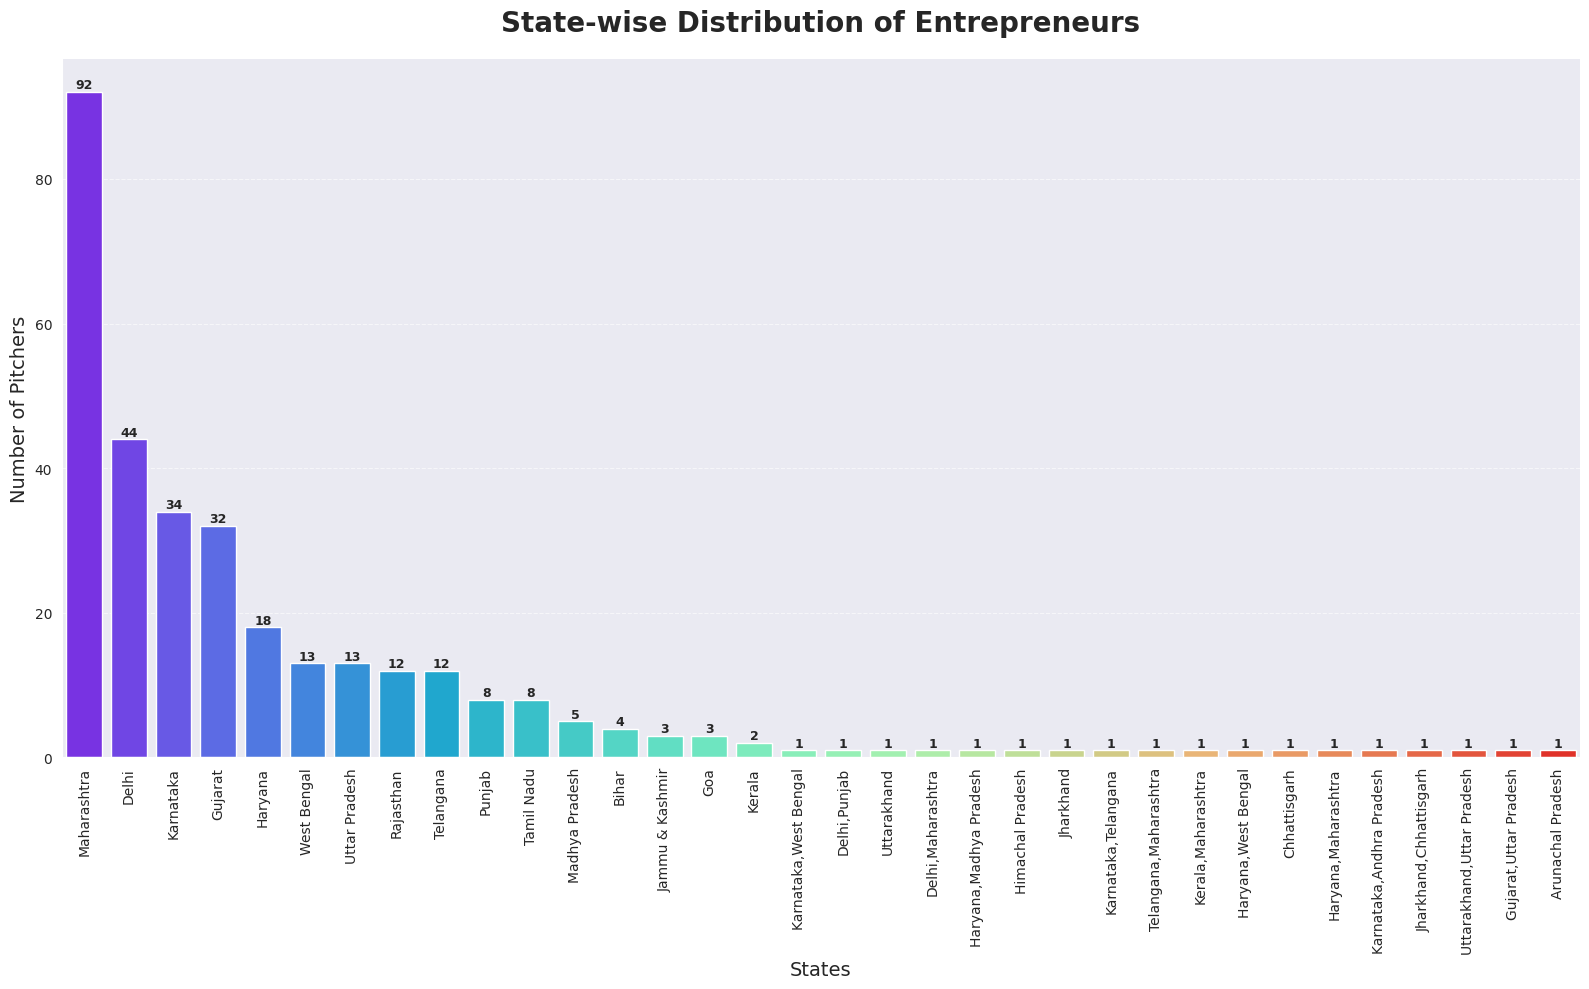

In [24]:
# Set visualization style
sns.set_style("darkgrid")

plt.figure(figsize=(16,10))

ax = sns.countplot(
    data=shark_tank,
    x='Pitchers State',
    order=shark_tank['Pitchers State'].value_counts().index,
    palette='rainbow'
)

# Add labels at the end of bars
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        int(bar.get_height()),
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

plt.title('State-wise Distribution of Entrepreneurs',
          fontsize=20,
          fontweight='bold',
          pad=20)

plt.ylabel('Number of Pitchers', fontsize=14)
plt.xlabel('States', fontsize=14)

plt.xticks(rotation=90, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)

sns.despine()

plt.tight_layout()
plt.show()

## Industry Representation in Shark Tank India

In [25]:
print(f"Industry-wise Distribution of Startups:\n\n{shark_tank['Industry'].value_counts()}")

Industry-wise Distribution of Startups:

Industry
Food                            82
Beauty/Fashion                  58
Manufacturing                   38
Services                        28
Technology/Software             26
Medical/Health                  24
Furnishing/Household            13
Vehicles/Electrical Vehicles    13
Education                        9
Sports                           7
Liquor/Beverages                 7
Animal/Pets                      5
Electronics                      4
Agriculture                      3
Hardware                         2
Entertainment                    2
Name: count, dtype: int64


In [26]:
tmp = shark_tank['Industry'].value_counts().sort_values(ascending=True)

fig = px.bar(
    x=tmp.values,
    y=tmp.index,
    orientation='h',
    text=tmp.values,
    title='<b>Industry-wise Distribution of Startups</b>',
    color=tmp.values,
    template='simple_white'
)

fig.update_layout(
    xaxis_title='Number of Startups',
    yaxis_title='Industry'
)

fig.show()

## Gender Distribution of Entrepreneurs

In [27]:
total_pitchers = shark_tank['Number of Presenters'].sum()
male_pitchers = shark_tank['Male Presenters'].sum()
female_pitchers = shark_tank['Female Presenters'].sum()

male_pct = round((male_pitchers / total_pitchers) * 100, 2)
female_pct = round((female_pitchers / total_pitchers) * 100, 2)
couple_pct = round(
    (shark_tank['Couple Presenters'].sum() / total_pitchers) * 100, 2
)

print("="*50)
print("     ENTREPRENEUR GENDER INSIGHTS")
print("="*50)

print(f" Total Presenters        : {int(total_pitchers)}")
print(f" Male Presenters         : {int(male_pitchers)}")
print(f" Female Presenters       : {int(female_pitchers)}")

print("\n Percentage Distribution")
print("-"*50)

print(f" Male Entrepreneurs      : {male_pct}%")
print(f" Female Entrepreneurs    : {female_pct}%")
print(f" Couple Entrepreneurs    : {couple_pct}% (Data may be incomplete)")

print("="*50)

     ENTREPRENEUR GENDER INSIGHTS
 Total Presenters        : 667
 Male Presenters         : 485
 Female Presenters       : 179

 Percentage Distribution
--------------------------------------------------
 Male Entrepreneurs      : 72.71%
 Female Entrepreneurs    : 26.84%
 Couple Entrepreneurs    : 8.85% (Data may be incomplete)


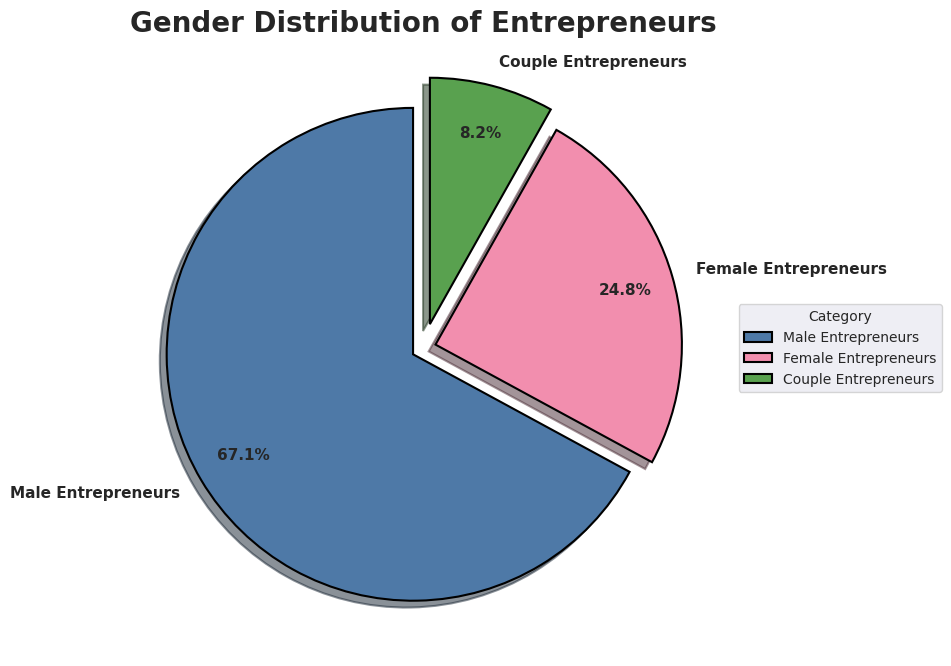

In [28]:

# Calculate values
total_pitchers = shark_tank['Number of Presenters'].sum()
male_pitchers = shark_tank['Male Presenters'].sum()
female_pitchers = shark_tank['Female Presenters'].sum()
couple_pitchers = shark_tank['Couple Presenters'].sum()

# Labels and values
labels = ['Male Entrepreneurs', 'Female Entrepreneurs', 'Couple Entrepreneurs']
sizes = [male_pitchers, female_pitchers, couple_pitchers]

# Explode effect
explode = (0.08, 0.08, 0.12)

# Create figure
plt.figure(figsize=(10,8))

colors = ['#4E79A7', '#F28EAE', '#59A14F']

plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    explode=(0.05, 0.05, 0.1),
    shadow=True,
    startangle=90,
    pctdistance=0.8,
    textprops={'fontsize':11, 'fontweight':'bold'},
    wedgeprops={'edgecolor':'black', 'linewidth':1.5}
)

plt.title('Gender Distribution of Entrepreneurs',
          fontsize=20,
          fontweight='bold')

plt.legend(title='Category',
           loc='center left',
           bbox_to_anchor=(1, 0.5))

plt.show()

# Top 10 Revenue-Generating Brands

In [29]:
top_revenue_brands = (
    shark_tank.groupby('Startup Name')['Yearly Revenue']
    .max()
    .nlargest(10)
    .reset_index()
)

top_revenue_brands.columns = ['Startup Name', 'Annual Revenue']

print(top_revenue_brands)

        Startup Name  Annual Revenue
0        FrenchCrown          7200.0
1             Rubans          5100.0
2           Toyshine          4500.0
3      GuardianGears          2500.0
4  GunjanAppsStudios          2400.0
5             UnStop          1600.0
6           StyloBug          1400.0
7  RaisingSuperstars          1300.0
8          DesmondJi          1200.0
9               Eume          1200.0


In [30]:
top_10 = shark_tank.nlargest(10, 'Yearly Revenue')

fig = px.bar(
    top_10,
    x='Startup Name',
    y='Yearly Revenue',
    color='Startup Name',
    text='Yearly Revenue',
    title='Top 10 Revenue-Generating Startups',
    template='plotly_dark'
)

fig.show()

# Top 10 Brands by Gross Margin

In [31]:
top_gross_margin = (
    shark_tank[['Startup Name', 'Gross Margin']]
    .sort_values(by='Gross Margin', ascending=False)
    .head(10)
)

top_gross_margin.style.background_gradient(cmap='YlGnBu')

,Startup Name,Gross Margin
69,Poo-de-Cologne,150.000000
33,Farda,115.000000
45,Cocofit,95.000000
230,UnStop,90.000000
256,MidNightAngelsByPC,83.000000
195,Pflow,80.000000
201,ekatra,80.000000
291,oyehappy,80.000000
225,LeafyAffair,80.000000
34,Auli,80.000000


In [32]:
highest_gross_margin = (
    shark_tank[['Startup Name', 'Gross Margin']]
    .sort_values(by='Gross Margin', ascending=False)
    .head(10)
)

fig = px.bar(
    highest_gross_margin,
    x='Startup Name',
    y='Gross Margin',
    color='Startup Name',
    text='Gross Margin',
    template='seaborn',
    title='Top 10 Brands with Highest Gross Margin'
)

fig.update_traces(textposition='inside')

fig.show()

### Acceptance vs Rejection of Shark Offers

In [33]:
shark_tank['Accepted Offer'].value_counts()

,count
Accepted Offer,
1.0,176
0.0,41


In [34]:
### Number of Entrepreneurs Accepting and Rejecting Shark Offers
accepted = shark_tank['Accepted Offer'].value_counts().iloc[0]
rejected = shark_tank['Accepted Offer'].value_counts().iloc[1]

print("=" * 55)
print("        SHARK OFFER OUTCOME ANALYSIS")
print("=" * 55)

print(f" Accepted Offers : {accepted}")
print(f" Rejected Offers : {rejected}")

print("=" * 55)

        SHARK OFFER OUTCOME ANALYSIS
 Accepted Offers : 176
 Rejected Offers : 41


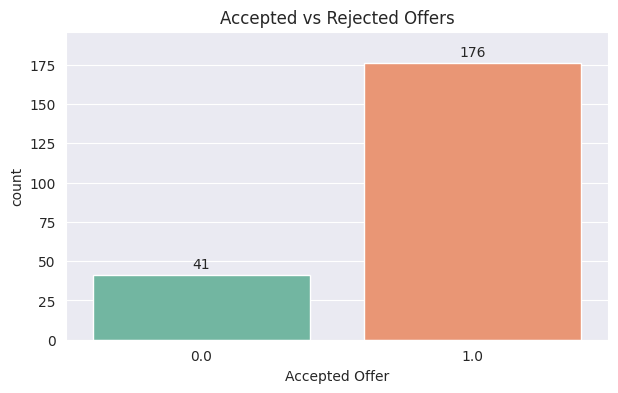

In [35]:
plt.figure(figsize=(7,4))

ax = sns.countplot(
    data=shark_tank,
    x='Accepted Offer',
    hue='Accepted Offer',
    palette='Set2',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title('Accepted vs Rejected Offers')
plt.ylim(0, shark_tank['Accepted Offer'].value_counts().max() + 20)

plt.show()

# Startups That Turned Down Shark Deals

In [36]:
# Startups that rejected the sharks' offers
startups_rejected_deals = shark_tank.loc[
    shark_tank['Accepted Offer'] == 0,
    [
        'Season Number',
        'Startup Name',
        'Business Description',
        'Original Ask Amount',
        'Original Offered Equity',
        'Valuation Requested'
    ]
]

startups_rejected_deals

,Season Number,Startup Name,Business Description,Original Ask Amount,Original Offered Equity,Valuation Requested
6,1,qZenseLabs,Food Freshness Detector,100.0,0.25,40000.000000
19,1,Torch-it,Gadgets for visually impaired people,75.0,1.00,7500.000000
21,1,LaKheerDeli,Kheer in variety of flavors,50.0,7.50,667.000000
27,1,KabiraHandmad,Healthy Edible Oils dairy products spices flour,100.0,5.00,2000.000000
41,1,MorrikoPureFoods,Healthy Food Snacks Kamdhenu foods,100.0,3.00,3333.000000
55,1,IndiaHempandCo,Hemp Food Products,50.0,4.00,1250.000000
60,1,KetoIndia,Customised Keto Diets for various Medical/Heal...,150.0,1.25,12000.000000
70,1,Moonshine,Meads,80.0,0.50,16000.000000
71,1,Falhari,Fresh Fruits salads,50.0,2.00,2500.000000
73,1,UrbanMonkey,Streetwear,100.0,1.00,10000.000000


# Industry-Wise Investment Trends Among Sharks

In [37]:
# Count the number of investments made by Ashneer in each industry
ashneer_industry_investments = (
    shark_tank[shark_tank['Ashneer Investment Amount'] > 0]
    ['Industry']
    .value_counts()
    .sort_values(ascending=False)
)

ashneer_industry_investments

,count
Industry,
Food,8
Vehicles/Electrical Vehicles,3
Education,3
Manufacturing,2
Beauty/Fashion,2
Animal/Pets,1
Sports,1
Technology/Software,1


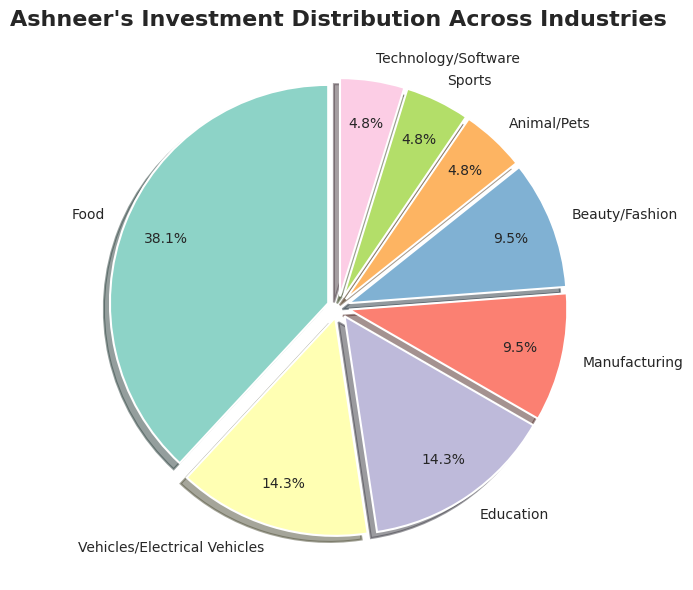

In [38]:
# Visualizing Ashneer's Industry-Wise Investment Distribution

plt.figure(figsize=(12, 6))

colors = plt.cm.Set3.colors

(
    shark_tank.loc[
        shark_tank['Ashneer Investment Amount'] > 0,
        'Industry'
    ]
    .value_counts()
    .sort_values(ascending=False)
    .plot.pie(
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        explode=[0.05] * shark_tank.loc[
            shark_tank['Ashneer Investment Amount'] > 0,
            'Industry'
        ].nunique(),
        shadow=True,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
        pctdistance=0.8,
        ylabel=''
    )
)

plt.title("Ashneer's Investment Distribution Across Industries",
          fontsize=16,
          fontweight='bold')

plt.tight_layout()
plt.show()

In [39]:
# Displaying Ashneer's Investments with Styling

tmpdf = (
    shark_tank.loc[
        shark_tank['Ashneer Investment Amount'] > 0,
        ['Startup Name',
         'Ashneer Investment Amount',
         'Ashneer Investment Equity']
    ]
    .sort_values(by='Ashneer Investment Equity')
)

tmpdf.style.background_gradient(cmap='Blues')

,Startup Name,Ashneer Investment Amount,Ashneer Investment Equity
30,EventBeep,10.000000,1.000000
56,Otua,1.000000,1.000000
22,BeyondSnack,25.000000,1.250000
68,HairOriginals,20.000000,1.330000
46,BambooIndia,25.000000,1.750000
18,RaisingSuperstars,50.000000,2.000000
64,INACAN,20.000000,2.000000
39,TheYarnBazaar,25.000000,2.500000
59,WeSTOCK,15.000000,2.500000
3,TagzFoods,70.000000,2.750000


In [40]:
tmpdf = shark_tank[shark_tank['Ashneer Investment Amount'] > 0][
    ['Startup Name', 'Ashneer Investment Amount', 'Ashneer Investment Equity']
].sort_values(by='Ashneer Investment Equity')

fig = px.bar(
    tmpdf,
    x='Ashneer Investment Equity',
    y='Ashneer Investment Amount',
    color='Startup Name',
    color_discrete_sequence=px.colors.qualitative.Bold,
    template='plotly_dark',
    title='<b>Ashneer: Equity vs Investment Amount</b>',
    text='Ashneer Investment Amount'   # Show values on bars
)

# Position the text above the bars
fig.update_layout(dict(xaxis = dict(type="category")))


fig.show()

**Ashneer stands out as the most active investor in the food sector, with a larger share of food-based startups in his portfolio than any other shark.**

# NAMITA'S INVESTMENT

In [41]:
# Analyzing Namita's Investment Preferences Across Industries

namita_industry_investments = (
    shark_tank.loc[
        shark_tank['Namita Investment Amount'] > 0,
        'Industry'
    ]
    .value_counts()
    .sort_values(ascending=False)
)

namita_industry_investments

,count
Industry,
Beauty/Fashion,13
Medical/Health,12
Food,11
Manufacturing,8
Services,6
Technology/Software,5
Education,3
Furnishing/Household,3
Sports,2


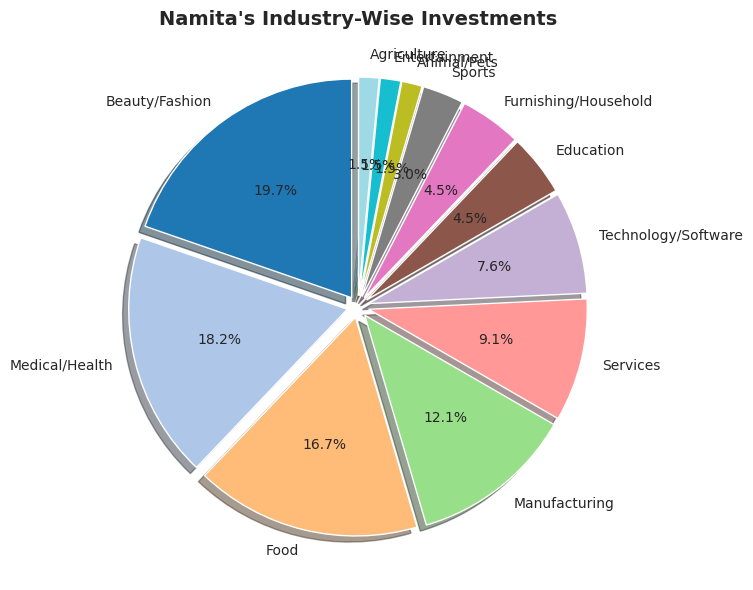

In [42]:
industry_counts = (
    shark_tank.loc[
        shark_tank['Namita Investment Amount'] > 0,
        'Industry'
    ]
    .value_counts()
)

plt.figure(figsize=(10, 6))

industry_counts.plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    cmap='tab20',
    shadow=True,
    explode=[0.05] * len(industry_counts),  # Correct length
    ylabel=''
)

plt.title("Namita's Industry-Wise Investments",
          fontsize=14,
          fontweight='bold')

plt.tight_layout()
plt.show()

#**Insight:**
##Namita's investment portfolio shows a stronger inclination toward Beauty and Fashion startups compared to Food-based ventures.

In [43]:
# Namita's Investment Portfolio and Equity Distribution
namita_portfolio = (
    shark_tank.loc[
        shark_tank['Namita Investment Amount'] > 0,
        [
            'Startup Name',
            'Namita Investment Amount',
            'Namita Investment Equity'
        ]
    ]
    .sort_values(by='Namita Investment Equity')
)

namita_portfolio

,Startup Name,Namita Investment Amount,Namita Investment Equity
159,Stage,50.00,0.200
209,Snitch,30.00,0.300
240,MindPeers,17.66,0.330
306,Rubans,33.33,0.333
279,GROWiT,25.00,0.500
...,...,...,...
34,Auli,75.00,15.000
16,Menstrupedia,50.00,20.000
160,Girgit,20.00,20.000
264,HoloKitab,45.00,25.000


In [44]:
tmpdf = shark_tank.loc[shark_tank['Namita Investment Amount']>0] [["Startup Name","Namita Investment Amount","Namita Investment Equity"]].sort_values(by="Namita Investment Equity")
fig = px.bar(tmpdf,
             x="Namita Investment Equity",
             y='Namita Investment Amount',
             color="Startup Name", template='plotly_dark',
             title='<b>Namita: Equity vs Investment Amount</b>',
             text=tmpdf['Namita Investment Amount'].map(int).map(str) + " lakhs")
fig.update_layout(dict(xaxis = dict(type="category")))
fig.show()

## Analyzing Anupam's Investment Strategy

In [45]:
# Exploring Anupam's Investment Trends Across Industries
anupam_industry_investments = (
    shark_tank[shark_tank['Anupam Investment Amount'] > 0]
    ['Industry']
    .value_counts()
)
anupam_industry_investments

,count
Industry,
Food,13
Beauty/Fashion,11
Manufacturing,7
Medical/Health,6
Technology/Software,3
Education,2
Vehicles/Electrical Vehicles,2
Animal/Pets,1
Sports,1


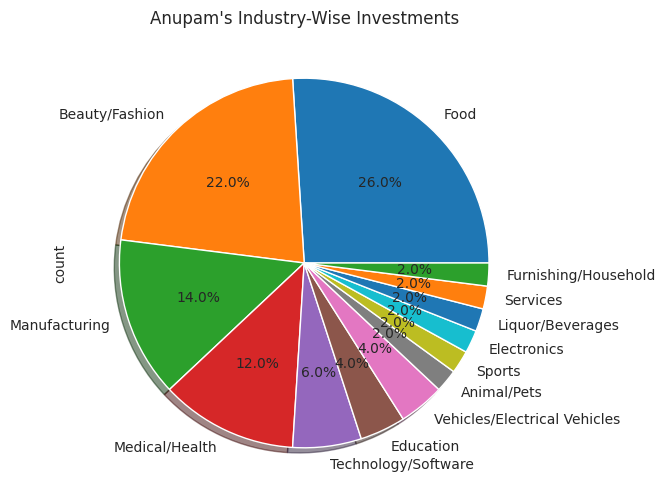

In [46]:
plt.figure(figsize=(12,6))

(shark_tank.loc[shark_tank['Anupam Investment Amount'] > 0, 'Industry']
 .value_counts().sort_values(ascending=False)
 .plot.pie(
     autopct='%1.1f%%',

     shadow=True
 ))

plt.title("Anupam's Industry-Wise Investments")
plt.show()

**Insight:** Similar to Ashneer, Food startups dominate Anupam's investment portfolio, followed closely by Beauty and Fashion ventures.

In [47]:
# Anupam's Investment Portfolio and Equity Distribution
anupam_portfolio = (
    shark_tank[shark_tank['Anupam Investment Amount'] > 0]
    [['Startup Name', 'Anupam Investment Amount', 'Anupam Investment Equity']]
    .sort_values('Anupam Investment Equity')
)

anupam_portfolio

,Startup Name,Anupam Investment Amount,Anupam Investment Equity
209,Snitch,30.000000,0.300
281,Trunome,37.500000,0.500
12,RevampMoto,50.000000,0.750
37,Annie,35.000000,1.000
219,PadCare,25.000000,1.000
230,UnStop,50.000000,1.000
86,WattTechnovations,0.000253,1.000
274,Pharmallama,40.000000,1.000
80,SunfoxTechnologies,20.000000,1.200
68,HairOriginals,20.000000,1.330


In [48]:
# Visualization Code
fig = px.bar(anupam_portfolio, x="Anupam Investment Equity", y='Anupam Investment Amount', color="Startup Name",
             template='plotly',
             title="<b>Total equity received by Anupam (in %) for investment (in lakhs)</b>",
             text=anupam_portfolio['Anupam Investment Amount'].map(int).map(str) + " lakhs")
fig.update_layout(dict(xaxis = dict(type="category")))
fig.show()

# Vineeta's Investment Portfolio

In [49]:
# Exploring Vineeta's Investment Trends Across Industries
vineeta_industry_investments = (
    shark_tank[shark_tank['Vineeta Investment Amount'] > 0]
    ['Industry']
    .value_counts()
)

vineeta_industry_investments

,count
Industry,
Food,17
Beauty/Fashion,10
Medical/Health,3
Manufacturing,3
Vehicles/Electrical Vehicles,2
Furnishing/Household,2
Liquor/Beverages,2
Electronics,1
Sports,1


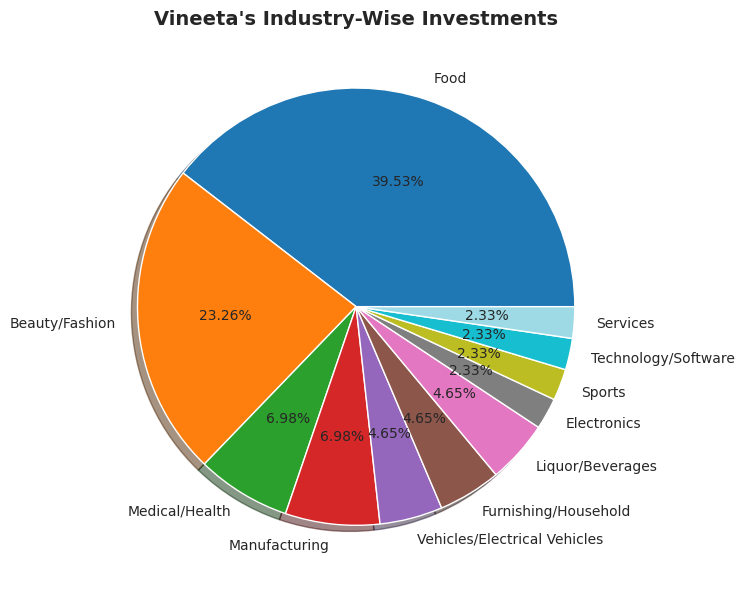

In [50]:
plt.figure(figsize=(10, 6))

(shark_tank.loc[shark_tank['Vineeta Investment Amount'] > 0, 'Industry']
 .value_counts()
 .plot.pie(
     autopct='%1.2f%%',
     cmap='tab20',
     shadow=True,
     ylabel=''
 ))

plt.title("Vineeta's Industry-Wise Investments",
          fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

**Insight:** Food startups dominate Vineeta's investment portfolio, accounting for 39.53% of her investments, followed by Beauty and Fashion startups at 23.26%.

In [51]:
vineeta_portfolio = (
    shark_tank[shark_tank['Vineeta Investment Amount'] > 0]
    [['Startup Name', 'Vineeta Investment Amount', 'Vineeta Investment Equity']]
    .sort_values('Vineeta Investment Equity')
)

vineeta_portfolio

,Startup Name,Vineeta Investment Amount,Vineeta Investment Equity
209,Snitch,30.00,0.300
240,MindPeers,17.66,0.330
306,Rubans,33.33,0.333
281,Trunome,37.50,0.500
255,Perfora,26.66,0.833
176,Paradyes,32.50,1.000
219,PadCare,25.00,1.000
80,SunfoxTechnologies,20.00,1.200
300,ThePlatedProject,25.00,1.250
283,What'sUpWellness,20.00,1.586


In [52]:

fig = px.bar(vineeta_portfolio, x="Vineeta Investment Equity",
             y='Vineeta Investment Amount',
             color="Startup Name",
             template='plotly_dark',
             title="<b>Vineeta: Equity vs Investment Amount</b>",
             text=vineeta_portfolio['Vineeta Investment Amount'].map(int).map(str) + " lakhs")
fig.update_layout(dict(xaxis = dict(type="category")))
fig.show()

# Aman's Investment Portfolio

In [53]:
aman_industry_investments = (
    shark_tank[shark_tank['Aman Investment Amount'] > 0]
    ['Industry']
    .value_counts()
)

aman_industry_investments

,count
Industry,
Food,18
Beauty/Fashion,14
Medical/Health,8
Manufacturing,7
Technology/Software,7
Services,7
Education,3
Vehicles/Electrical Vehicles,3
Liquor/Beverages,2


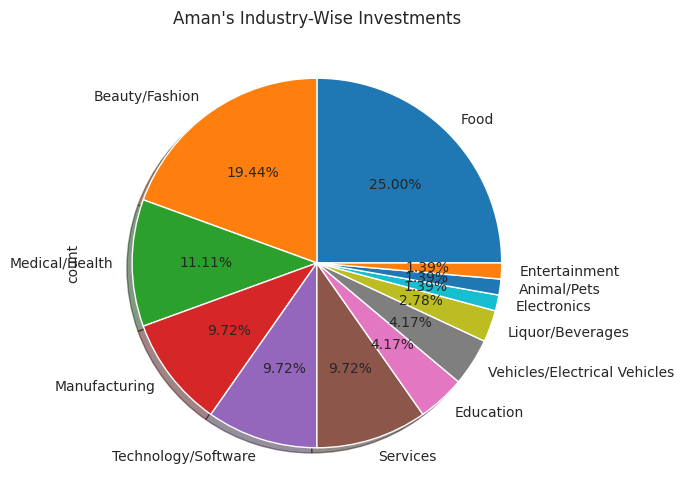

In [54]:
# Plotting the chart
plt.figure(figsize=(12,6))
(shark_tank[shark_tank['Aman Investment Amount']>0]['Industry']
 .value_counts().
 sort_values(ascending=False)
 .plot.pie(autopct='%1.2f%%',
            shadow=True,)
)

plt.title("Aman's Industry-Wise Investments")
plt.show()

**Insight:** Aman's investment portfolio is primarily dominated by Food and Beauty/Fashion startups, with other sectors making up a smaller share.

In [55]:
# Aman's Investment Portfolio and Equity Distribution
aman_portfolio = (
    shark_tank[shark_tank['Aman Investment Amount'] > 0]
    [['Startup Name', 'Aman Investment Amount', 'Aman Investment Equity']]
    .sort_values('Aman Investment Equity')
)

aman_portfolio

,Startup Name,Aman Investment Amount,Aman Investment Equity
159,Stage,50.00,0.200
277,Hood,30.00,0.270
209,Snitch,30.00,0.300
240,MindPeers,17.66,0.330
306,Rubans,33.33,0.333
...,...,...,...
33,Farda,15.00,10.000
72,NamhyaFoods,50.00,10.000
228,Manetain,75.00,10.000
213,Dabble,15.00,10.000


In [56]:

fig = px.bar(aman_portfolio, x="Aman Investment Equity",
             y='Aman Investment Amount',
             color="Startup Name",
             template='plotly',
            title='<b>Aman: Equity vs Investment Amount</b>',
             text=aman_portfolio['Aman Investment Amount'].map(int).map(str) + " lakhs")
fig.update_layout(dict(xaxis = dict(type="category")))
fig.show()

## Peyush's Investment Portfolio

In [57]:
# Exploring Peyush's Investment Trends Across Industries
peyush_industry_investments = (
    shark_tank[shark_tank['Peyush Investment Amount'] > 0]
    ['Industry']
    .value_counts()
)

peyush_industry_investments

,count
Industry,
Medical/Health,11
Manufacturing,11
Food,8
Technology/Software,8
Services,8
Beauty/Fashion,7
Education,3
Liquor/Beverages,2
Agriculture,2


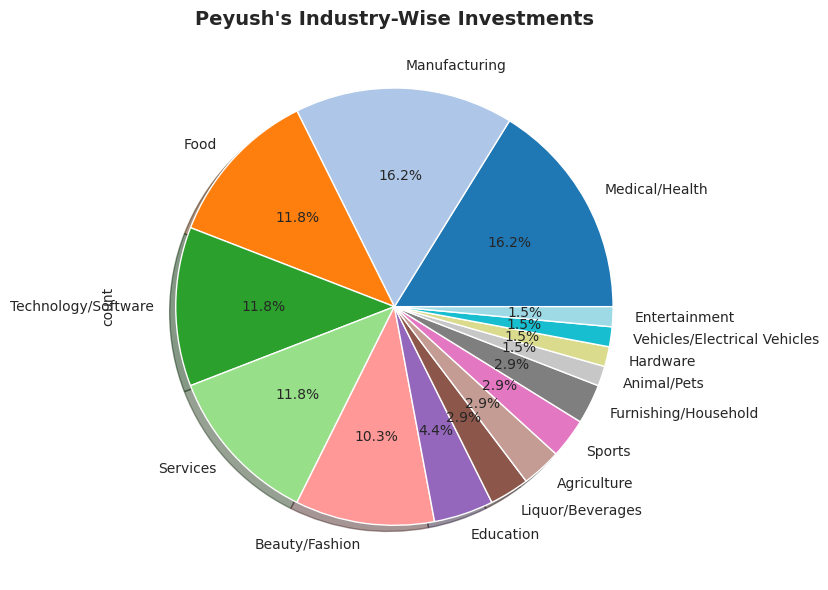

In [58]:
plt.figure(figsize=(15, 6))

(peyush_industry_investments
 .sort_values(ascending=False)
 .plot.pie(
     autopct='%1.1f%%',
     cmap='tab20',
     shadow=True,
 )
 )


plt.title("Peyush's Industry-Wise Investments",
          fontsize=14,
          fontweight='bold')

plt.tight_layout()
plt.show()

**Insight:** Peyush's investment portfolio is largely concentrated in the Medical/Health, Manufacturing, Technology/Software, and Food sectors.

In [59]:
# Exploring Peyush's Investment Trends

peyush_portfolio = shark_tank.loc[shark_tank['Peyush Investment Amount']>0] [["Startup Name","Peyush Investment Amount","Peyush Investment Equity"]].sort_values(by="Peyush Investment Equity")
fig = px.bar(peyush_portfolio,
             x="Peyush Investment Equity",
             y='Peyush Investment Amount',
             color="Startup Name",
             template='plotly',
              title='<b>Peyush: Equity vs Investment Amount</b>',
             text=peyush_portfolio['Peyush Investment Amount'].map(int).map(str) + " lakhs")
fig.update_layout(dict(xaxis = dict(type="category")))
fig.show()

# Ghazal's Investment Portfolio

In [60]:
# Exploring Ghazal's Investment Trends Across Industries
ghazal_industry_investments = (
    shark_tank[shark_tank['Ghazal Investment Amount'] > 0]
    ['Industry']
    .value_counts()
)

ghazal_industry_investments

,count
Industry,
Food,3
Medical/Health,2
Manufacturing,2
Beauty/Fashion,1


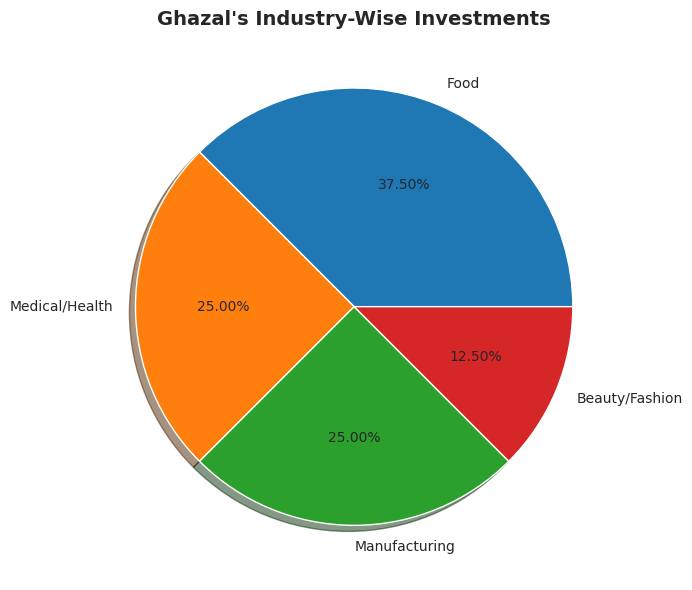

In [61]:
# Visualizing Ghazal's Industry-Wise Investments
plt.figure(figsize=(12,6))
(ghazal_industry_investments.sort_values(ascending=False)
.plot.pie
 (autopct='%1.2f%%',
  shadow=True,
  ylabel='')
 )
plt.title("Ghazal's Industry-Wise Investments",
          fontsize=14,
          fontweight='bold')

plt.tight_layout()
plt.show()

**Insight:** Ghazal's investment portfolio spans only four industries, making it the most focused and streamlined portfolio among all the sharks.

In [62]:
# Ghazal's Investment Portfolio and Equity Distribution
ghazal_portfolio = (
    shark_tank[shark_tank['Ghazal Investment Amount'] > 0]
    [['Startup Name', 'Ghazal Investment Amount', 'Ghazal Investment Equity']]
    .sort_values('Ghazal Investment Equity')
)

ghazal_portfolio

,Startup Name,Ghazal Investment Amount,Ghazal Investment Equity
86,WattTechnovations,0.000253,1.0
80,SunfoxTechnologies,20.000000,1.2
89,HumpyA2,33.330000,5.0
122,WitBlox,30.000000,5.0
111,NomadFoodProject,10.000000,5.0
92,WakaoFoods,25.000000,7.0
91,GoldSafeSolutions,16.660000,10.0
76,TheSassBar,25.000000,17.5


In [63]:
# Visualization Code
ghazal_portfolio
fig = px.bar(ghazal_portfolio,
             x="Ghazal Investment Equity",
             y='Ghazal Investment Amount',
             color="Startup Name", template='plotly',
              title='<b>Ghazal: Equity vs Investment Amount</b>',
             text=ghazal_portfolio['Ghazal Investment Amount'].map(int).map(str) + " lakhs")
fig.update_layout(dict(xaxis = dict(type="category")))
fig.show()

# Amit's Investment Portfolio

In [64]:
# Exploring Amit's Investment Trends Across Industries

amit_industry_investments = (
    shark_tank.loc[
        shark_tank['Amit Investment Amount'] > 0,
        'Industry'
    ]
    .value_counts()
    .sort_values(ascending=False)
)

amit_industry_investments

,count
Industry,
Food,6
Beauty/Fashion,5
Medical/Health,3
Services,2
Technology/Software,2
Manufacturing,1
Furnishing/Household,1
Vehicles/Electrical Vehicles,1


<Axes: >

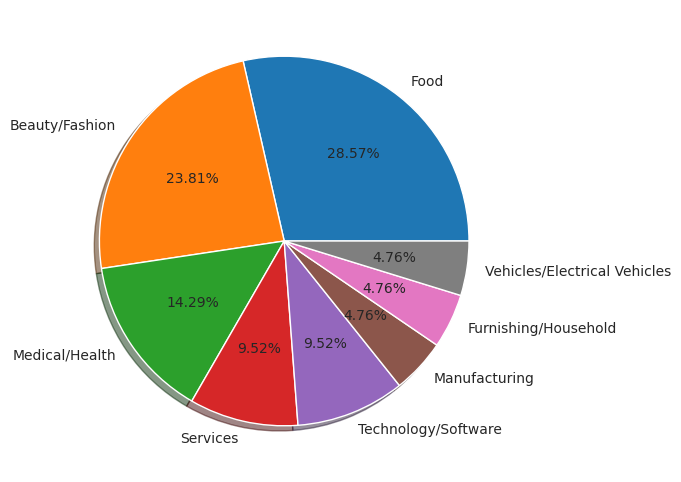

In [65]:
# Plotting the chart
plt.figure(figsize=(12,6))
(amit_industry_investments
 .plot.pie
  (autopct='%1.2f%%',
   shadow=True,
     ylabel=''
  )
)

**Insight:** Amit's investment portfolio is primarily concentrated in the Food and Beauty/Fashion sectors.

In [66]:
amit_portfolio = (
    shark_tank[shark_tank['Amit Investment Amount'] > 0]
    [['Startup Name', 'Amit Investment Amount', 'Amit Investment Equity']]
    .sort_values('Amit Investment Equity')
)

amit_portfolio

,Startup Name,Amit Investment Amount,Amit Investment Equity
274,Pharmallama,40.00,1.0000
230,UnStop,50.00,1.0000
313,maisha,10.00,1.0000
273,GladFul,16.66,1.1666
290,Aadvik,15.00,1.5000
271,nawgati,33.50,1.5000
311,Sahayatha,20.00,2.0000
314,NishHair,100.00,2.0000
289,funngro,25.00,2.0800
266,Hornback,50.00,2.5000


In [67]:
# Visualizing Amit's Investment Portfolio

tmpdf = shark_tank.loc[shark_tank['Amit Investment Amount']>0] [["Startup Name","Amit Investment Amount","Amit Investment Equity"]].sort_values(by="Amit Investment Equity")
fig = px.bar(tmpdf, x="Amit Investment Equity", y='Amit Investment Amount', color="Startup Name", template='plotly', title="<b>Total equity received by Amit (in %) for investment (in lakhs)</b>", text=tmpdf['Amit Investment Amount'].map(int).map(str) + " lakhs")
fig.update_layout(dict(xaxis = dict(type="category")))
fig.show()

# Guest Shark Investment Analysis

In [68]:
# Displaying the Guest Shark's Name

guest_name = shark_tank.loc[
    shark_tank['Guest Name'] == 'Vikas',
    'Guest Name'
].iloc[0]

print(f"Guest Shark: {guest_name}")

Guest Shark: Vikas


In [69]:
# Finding the count of various Industries
shark_tank[shark_tank['Guest Investment Amount']>0]['Industry'].value_counts().sort_values(ascending=False)

,count
Industry,
Beauty/Fashion,1
Liquor/Beverages,1


<Axes: >

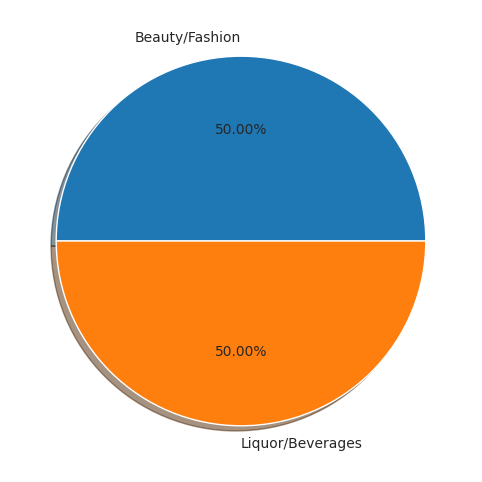

In [70]:
# Plotting the chart
plt.figure(figsize=(12,6))
shark_tank[shark_tank['Guest Investment Amount']>0]['Industry'].value_counts().sort_values(ascending=False).plot.pie(autopct='%1.2f%%',shadow=True,ylabel='')

**Insight:** The Guest Shark's investment portfolio is evenly distributed between the Beauty/Fashion and Liquor/Beverages sectors.

In [71]:
# Viewing the DataFrame
tmpdf = shark_tank.loc[shark_tank['Guest Investment Amount']>0] [["Startup Name","Guest Investment Amount","Guest Investment Equity"]].sort_values(by="Guest Investment Equity")
tmpdf

,Startup Name,Guest Investment Amount,Guest Investment Equity
317,TAC,40.5,0.5
318,Naara-Aaba,25.0,2.5


In [72]:
# Visualization Code
tmpdf = shark_tank.loc[shark_tank['Guest Investment Amount']>0] [["Startup Name","Guest Investment Amount","Guest Investment Equity"]].sort_values(by="Guest Investment Equity")
fig = px.bar(tmpdf, x="Guest Investment Equity", y='Guest Investment Amount', color="Startup Name", template='plotly_dark', title="<b>Guest Shark: Investment Amount vs Equity Stake</b>", text=tmpdf['Guest Investment Amount'].map(int).map(str) + " lakhs")
fig.update_layout(dict(xaxis = dict(type="category")))
fig.show()

# Number of Sharks Participating in Each Deal

Number of sharks in deal
1.0    42%
2.0    31%
3.0    16%
4.0     7%
5.0     5%
Name: proportion, dtype: object


/tmp/ipykernel_18891/3725450628.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




<Axes: xlabel='Number of sharks in deal', ylabel='count'>

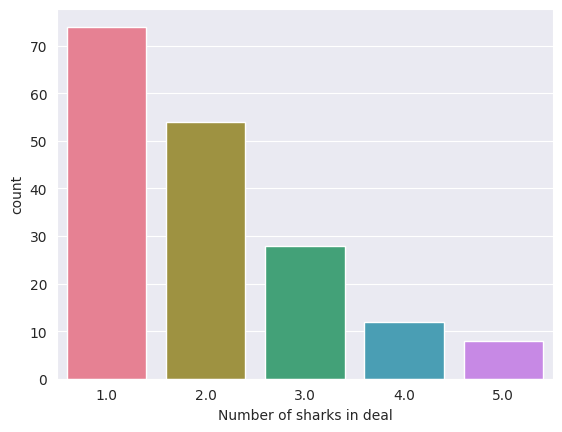

In [73]:
# Visualization Code
print(round(shark_tank['Number of sharks in deal'].value_counts(normalize=True) * 100).astype(str).str.replace('.0','%'))
sns.countplot(data=shark_tank,x='Number of sharks in deal',palette='husl')

In [74]:
# Startups with Five or More Sharks in the Deal

multi_shark_deals = (
    shark_tank.loc[
        shark_tank['Number of sharks in deal'] >= 5,
        ['Startup Name', 'Total Deal Amount', 'Total Deal Equity']
    ]
)

multi_shark_deals

,Startup Name,Total Deal Amount,Total Deal Equity
15,SkippiIcePops,100.0,15.0
50,FindYourKicksIndia,50.0,25.0
64,INACAN,100.0,10.0
80,SunfoxTechnologies,100.0,6.0
209,Snitch,150.0,1.5
239,Mahantam,30.0,20.0
274,Pharmallama,200.0,5.0
311,Sahayatha,100.0,10.0


# Total Investment Sought by Pitchers

In [75]:
# Calculating the Total Funding Requested by Startups
from babel.numbers import format_currency
total_ask = shark_tank['Original Ask Amount'].sum() / 100

print(
    format_currency(
        total_ask,
        'INR',
        locale='en_IN'
    ).replace('.00', ''),
    'crores'
)

₹541.41 crores


# Total Investment Made by the Sharks

In [76]:
# Calculating the Total Investment Made by the Sharks

total_investment = shark_tank['Total Deal Amount'].sum() / 100

print(
    format_currency(
        total_investment,
        'INR',
        locale='en_IN'
    ).replace('.00', ''),
    'crores'
)

₹110.06 crores


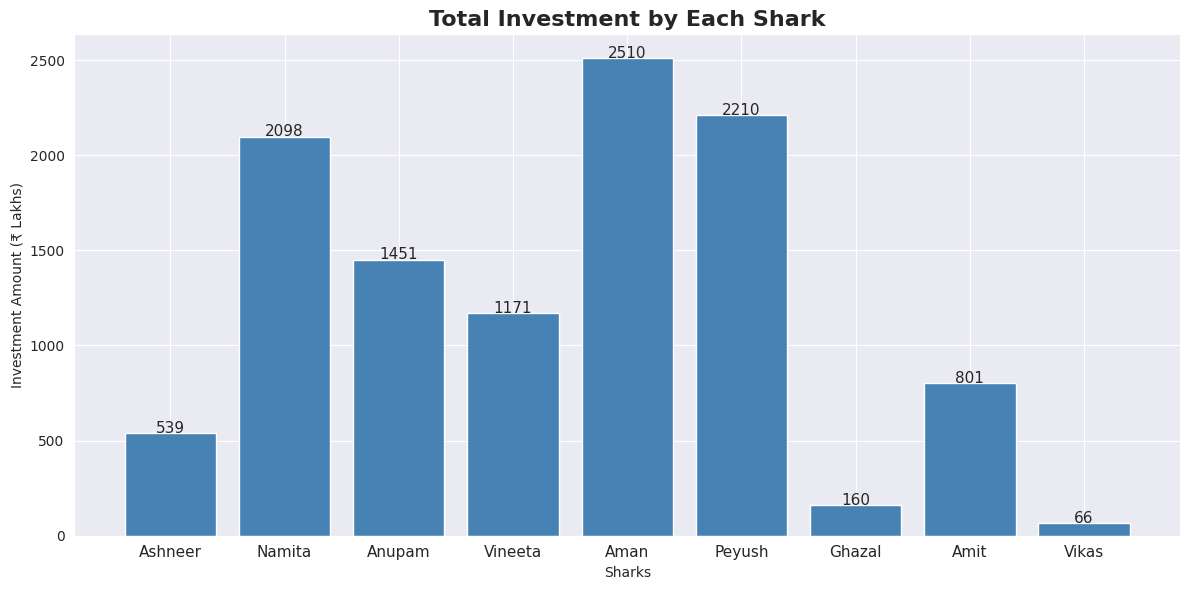

In [77]:
# Visualizing Total Investment Amount by Each Shark

investment_summary = {
    'Name': ['Ashneer', 'Namita', 'Anupam', 'Vineeta', 'Aman',
             'Peyush', 'Ghazal', 'Amit', 'Vikas'],
    'Total Investment': [
        shark_tank['Ashneer Investment Amount'].sum(),
        shark_tank['Namita Investment Amount'].sum(),
        shark_tank['Anupam Investment Amount'].sum(),
        shark_tank['Vineeta Investment Amount'].sum(),
        shark_tank['Aman Investment Amount'].sum(),
        shark_tank['Peyush Investment Amount'].sum(),
        shark_tank['Ghazal Investment Amount'].sum(),
        shark_tank['Amit Investment Amount'].sum(),
        shark_tank['Guest Investment Amount'].sum()
    ]
}

investment_df = pd.DataFrame(investment_summary)

plt.figure(figsize=(12, 6))

bars = plt.bar(
    investment_df['Name'],
    investment_df['Total Investment'],
    color='steelblue'
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        f'{bar.get_height():.0f}',
        ha='center',
        fontsize=11
    )

plt.title('Total Investment by Each Shark', fontsize=16, fontweight='bold')
plt.xlabel('Sharks')
plt.ylabel('Investment Amount (₹ Lakhs)')
plt.xticks(fontsize=11)

plt.tight_layout()
plt.show()

# Total Investment Made by the Sharks

In [78]:
# Calculating the Total Debt Provided by the Sharks

total_debt = shark_tank['Total Deal Debt'].sum() / 100

print(
    format_currency(
        total_debt,
        'INR',
        locale='en_IN'
    ).replace('.00', ''),
    'crores'
)

₹18.11 crores


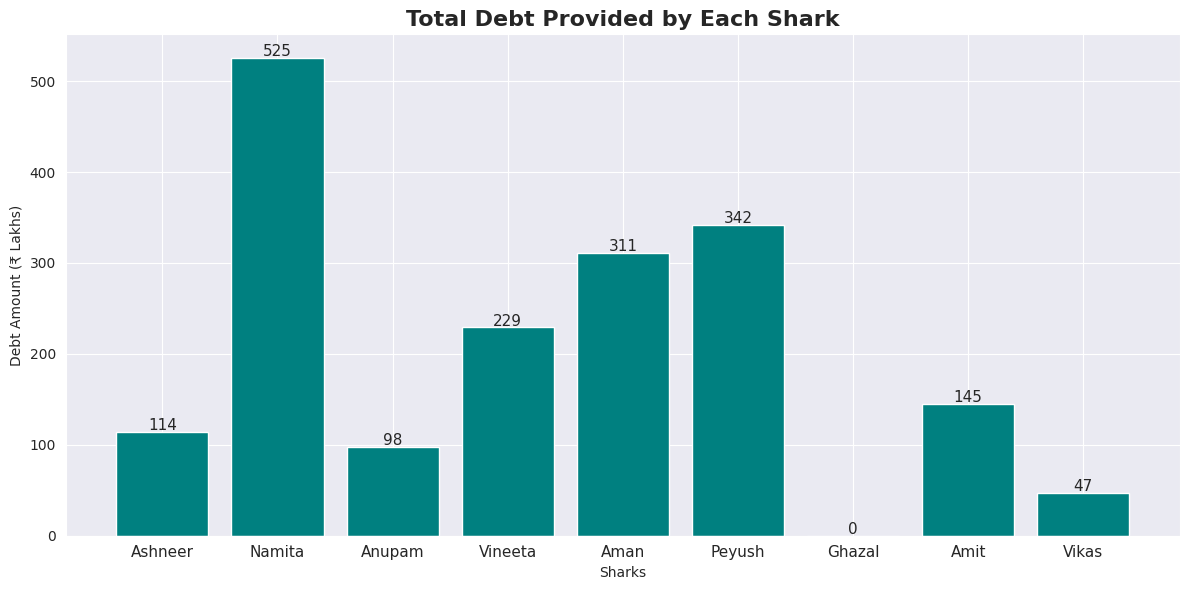

In [79]:
# Visualizing Total Debt Provided by Each Shark

debt_summary = {
    'Name': ['Ashneer', 'Namita', 'Anupam', 'Vineeta', 'Aman',
             'Peyush', 'Ghazal', 'Amit', 'Vikas'],
    'Total Debt': [
        shark_tank['Ashneer Debt Amount'].sum(),
        shark_tank['Namita Debt Amount'].sum(),
        shark_tank['Anupam Debt Amount'].sum(),
        shark_tank['Vineeta Debt Amount'].sum(),
        shark_tank['Aman Debt Amount'].sum(),
        shark_tank['Peyush Debt Amount'].sum(),
        shark_tank['Ghazal Debt Amount'].sum(),
        shark_tank['Amit Debt Amount'].sum(),
        shark_tank['Guest Debt Amount'].sum()
    ]
}

debt_df = pd.DataFrame(debt_summary)

plt.figure(figsize=(12, 6))

bars = plt.bar(
    debt_df['Name'],
    debt_df['Total Debt'],
    color='teal'
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        f'{bar.get_height():.0f}',
        ha='center',
        fontsize=11
    )

plt.title('Total Debt Provided by Each Shark', fontsize=16, fontweight='bold')
plt.xlabel('Sharks')
plt.ylabel('Debt Amount (₹ Lakhs)')
plt.xticks(fontsize=11)

plt.tight_layout()
plt.show()

# Comparing the Investment Portfolios of the Sharks

# Analyzing Peyush's Portfolio

In [80]:
# Peyush's Investment Summary

total_investments = shark_tank['Peyush Investment Amount'].gt(0).sum()
total_amount = shark_tank['Peyush Investment Amount'].sum() / 100
total_equity = shark_tank['Peyush Investment Equity'].sum()
total_debt = shark_tank['Peyush Debt Amount'].sum() / 100

print("=" * 60)
print(" PEYUSH'S INVESTMENT SUMMARY")
print("=" * 60)

print(f" Total Startups Invested : {total_investments}")
print(f" Total Investment       : ₹{total_amount:.2f} Crores")
print(f" Total Equity Acquired  : {total_equity:.2f}%")
print(f" Total Debt Provided    : ₹{total_debt:.2f} Crores")

print("=" * 60)

peyush_portfolio = (
    shark_tank.loc[
        shark_tank['Peyush Investment Amount'] > 0,
        ['Startup Name', 'Industry', 'Peyush Investment Amount']
    ]
    .sort_values('Peyush Investment Amount', ascending=False)
    .reset_index(drop=True)
)

peyush_portfolio[:40]

 PEYUSH'S INVESTMENT SUMMARY
 Total Startups Invested : 68
 Total Investment       : ₹22.10 Crores
 Total Equity Acquired  : 422.11%
 Total Debt Provided    : ₹3.42 Crores


,Startup Name,Industry,Peyush Investment Amount
0,NeoMotion,Manufacturing,100.00
1,InsuranceSamadhan,Services,100.00
2,RoadBounce,Technology/Software,80.00
3,MeduLance,Medical/Health,66.66
4,MindPeers,Medical/Health,53.00
5,Portl,Services,50.00
6,CureSee,Medical/Health,50.00
7,neuphony,Medical/Health,50.00
8,LilGoodness,Food,50.00
9,Hoovu,Services,50.00


# Analyzing Aman's Portfolio

In [81]:
#  Aman's Investment Summary

total_investments = shark_tank['Aman Investment Amount'].gt(0).sum()
total_amount = shark_tank['Aman Investment Amount'].sum() / 100
total_equity = shark_tank['Aman Investment Equity'].sum()
total_debt = shark_tank['Aman Debt Amount'].sum() / 100

print("=" * 60)
print(" AMAN GUPTA'S INVESTMENT SUMMARY")
print("=" * 60)

print(f" Total Startups Invested : {total_investments}")
print(f" Total Investment       : ₹{total_amount:.2f} Crores")
print(f" Total Equity Acquired  : {total_equity:.2f}%")
print(f" Total Debt Provided    : ₹{total_debt:.2f} Crores")

print("=" * 60)

aman_portfolio = (
    shark_tank.loc[
        shark_tank['Aman Investment Amount'] > 0,
        ['Startup Name', 'Industry', 'Aman Investment Amount']
    ]
    .sort_values('Aman Investment Amount', ascending=False)
    .reset_index(drop=True)
)

aman_portfolio[:40]

 AMAN GUPTA'S INVESTMENT SUMMARY
 Total Startups Invested : 72
 Total Investment       : ₹25.10 Crores
 Total Equity Acquired  : 260.93%
 Total Debt Provided    : ₹3.11 Crores


,Startup Name,Industry,Aman Investment Amount
0,Zoff,Food,100.00
1,HammerLifestyle,Electronics,100.00
2,Daryaganj,Food,90.00
3,Wol3D,Manufacturing,80.00
4,Peeschute,Beauty/Fashion,75.00
5,Manetain,Beauty/Fashion,75.00
6,AyuRythm,Medical/Health,75.00
7,MeduLance,Medical/Health,66.66
8,GharSoaps,Beauty/Fashion,60.00
9,BlueTea,Food,50.00


# Analyzing Ghazal's Portfolio

In [82]:
#  Ghazal Alagh's Investment Summary

total_investments = shark_tank['Ghazal Investment Amount'].gt(0).sum()
total_amount = shark_tank['Ghazal Investment Amount'].sum() / 100
total_equity = shark_tank['Ghazal Investment Equity'].sum()
total_debt = shark_tank['Ghazal Debt Amount'].sum() / 100

print("=" * 60)
print(" GHAZAL ALAGH'S INVESTMENT SUMMARY")
print("=" * 60)

print(f" Total Startups Invested : {total_investments}")
print(f" Total Investment       : ₹{total_amount:.2f} Crores")
print(f" Total Equity Acquired  : {total_equity:.2f}%")
print(f" Total Debt Provided    : ₹{total_debt:.2f} Crores")

print("=" * 60)

ghazal_portfolio = (
    shark_tank.loc[
        shark_tank['Ghazal Investment Amount'] > 0,
        ['Startup Name', 'Industry', 'Ghazal Investment Amount']
    ]
    .sort_values('Ghazal Investment Amount', ascending=False)
    .reset_index(drop=True)
)

ghazal_portfolio

 GHAZAL ALAGH'S INVESTMENT SUMMARY
 Total Startups Invested : 8
 Total Investment       : ₹1.60 Crores
 Total Equity Acquired  : 51.70%
 Total Debt Provided    : ₹0.00 Crores


,Startup Name,Industry,Ghazal Investment Amount
0,HumpyA2,Food,33.330000
1,WitBlox,Manufacturing,30.000000
2,WakaoFoods,Food,25.000000
3,TheSassBar,Beauty/Fashion,25.000000
4,SunfoxTechnologies,Medical/Health,20.000000
5,GoldSafeSolutions,Manufacturing,16.660000
6,NomadFoodProject,Food,10.000000
7,WattTechnovations,Medical/Health,0.000253


In [83]:
# Function to simplify industry names

def split_industry(category):
    parts = category.split('/')

    if parts[0] == 'Vehicles':
        return parts[1]

    return category

In [84]:
# Updating the Industry Column

shark_tank['Industry'] = shark_tank['Industry'].apply(split_industry)

# Analyzing Ashneer's Portfolio

In [85]:
#  Ashneer Grover's Investment Summary

total_investments = shark_tank['Ashneer Investment Amount'].gt(0).sum()
total_amount = shark_tank['Ashneer Investment Amount'].sum() / 100
total_equity = shark_tank['Ashneer Investment Equity'].sum()
total_debt = shark_tank['Ashneer Debt Amount'].sum() / 100

print("=" * 60)
print(" ASHNEER GROVER'S INVESTMENT SUMMARY")
print("=" * 60)

print(f" Total Startups Invested : {total_investments}")
print(f" Total Investment       : ₹{total_amount:.2f} Crores")
print(f" Total Equity Acquired  : {total_equity:.2f}%")
print(f" Total Debt Provided    : ₹{total_debt:.2f} Crores")

print("=" * 60)

ashneer_portfolio = (
    shark_tank.loc[
        shark_tank['Ashneer Investment Amount'] > 0,
        ['Startup Name', 'Industry', 'Ashneer Investment Amount']
    ]
    .sort_values('Ashneer Investment Amount', ascending=False)
    .reset_index(drop=True)
)

ashneer_portfolio

 ASHNEER GROVER'S INVESTMENT SUMMARY
 Total Startups Invested : 21
 Total Investment       : ₹5.39 Crores
 Total Equity Acquired  : 93.24%
 Total Debt Provided    : ₹1.14 Crores


,Startup Name,Industry,Ashneer Investment Amount
0,TagzFoods,Food,70.00
1,RaisingSuperstars,Education,50.00
2,AasVidyalaya,Education,50.00
3,Proxgy,Technology/Software,50.00
4,Get-A-Whey,Food,33.33
5,MotionBreeze,Electrical Vehicles,30.00
6,BambooIndia,Manufacturing,25.00
7,BluePineFoods,Food,25.00
8,BeyondSnack,Food,25.00
9,TheYarnBazaar,Manufacturing,25.00


# Analyzing Namita's Portfolio

In [86]:
#  Namita Thapar's Investment Summary

total_investments = shark_tank['Namita Investment Amount'].gt(0).sum()
total_amount = shark_tank['Namita Investment Amount'].sum() / 100
total_equity = shark_tank['Namita Investment Equity'].sum()
total_debt = shark_tank['Namita Debt Amount'].sum() / 100

print("=" * 60)
print(" NAMITA THAPAR'S INVESTMENT SUMMARY")
print("=" * 60)

print(f" Total Startups Invested : {total_investments}")
print(f" Total Investment       : ₹{total_amount:.2f} Crores")
print(f" Total Equity Acquired  : {total_equity:.2f}%")
print(f" Total Debt Provided    : ₹{total_debt:.2f} Crores")

print("=" * 60)

namita_portfolio = (
    shark_tank.loc[
        shark_tank['Namita Investment Amount'] > 0,
        ['Startup Name', 'Industry', 'Namita Investment Amount']
    ]
    .sort_values('Namita Investment Amount', ascending=False)
    .reset_index(drop=True)
)

namita_portfolio.head(30)

 NAMITA THAPAR'S INVESTMENT SUMMARY
 Total Startups Invested : 66
 Total Investment       : ₹20.98 Crores
 Total Equity Acquired  : 301.59%
 Total Debt Provided    : ₹5.25 Crores


,Startup Name,Industry,Namita Investment Amount
0,Janitri,Medical/Health,100.00
1,Auli,Beauty/Fashion,75.00
2,LondonBubble,Food,75.00
3,SpiceStory,Food,70.00
4,MeduLance,Medical/Health,66.66
5,RarePlanet,Manufacturing,65.00
6,UnStop,Technology/Software,50.00
7,Portl,Services,50.00
8,TheRenalProject,Medical/Health,50.00
9,Menstrupedia,Education,50.00


# Analyzing Anupam's Portfolio

In [87]:
#  Anupam Mittal's Investment Summary

total_investments = shark_tank['Anupam Investment Amount'].gt(0).sum()
total_amount = shark_tank['Anupam Investment Amount'].sum() / 100
total_equity = shark_tank['Anupam Investment Equity'].sum()
total_debt = shark_tank['Anupam Debt Amount'].sum() / 100

print("=" * 60)
print(" ANUPAM MITTAL'S INVESTMENT SUMMARY")
print("=" * 60)

print(f" Total Startups Invested : {total_investments}")
print(f" Total Investment       : ₹{total_amount:.2f} Crores")
print(f" Total Equity Acquired  : {total_equity:.2f}%")
print(f" Total Debt Provided    : ₹{total_debt:.2f} Crores")

print("=" * 60)

anupam_portfolio = (
    shark_tank.loc[
        shark_tank['Anupam Investment Amount'] > 0,
        ['Startup Name', 'Industry', 'Anupam Investment Amount']
    ]
    .sort_values('Anupam Investment Amount', ascending=False)
    .reset_index(drop=True)
)

anupam_portfolio.head(30)

 ANUPAM MITTAL'S INVESTMENT SUMMARY
 Total Startups Invested : 50
 Total Investment       : ₹14.51 Crores
 Total Equity Acquired  : 305.83%
 Total Debt Provided    : ₹0.97 Crores


,Startup Name,Industry,Anupam Investment Amount
0,Zillionaire,Beauty/Fashion,100.00
1,Ravel,Beauty/Fashion,75.00
2,Amore,Food,75.00
3,Raasa,Food,50.00
4,UnStop,Technology/Software,50.00
5,Winston,Beauty/Fashion,50.00
6,PawsIndia,Animal/Pets,50.00
7,WatchoutWearables,Electronics,50.00
8,ARRCOATSurfaceTextures,Manufacturing,50.00
9,Homestrap,Furnishing/Household,50.00


# Analyzing Vineeta's Portfolio

In [88]:
#  Vineeta Singh's Investment Summary

total_investments = shark_tank['Vineeta Investment Amount'].gt(0).sum()
total_amount = shark_tank['Vineeta Investment Amount'].sum() / 100
total_equity = shark_tank['Vineeta Investment Equity'].sum()
total_debt = shark_tank['Vineeta Debt Amount'].sum() / 100

print("=" * 60)
print(" VINEETA SINGH'S INVESTMENT SUMMARY")
print("=" * 60)

print(f" Total Startups Invested : {total_investments}")
print(f" Total Investment       : ₹{total_amount:.2f} Crores")
print(f" Total Equity Acquired  : {total_equity:.2f}%")
print(f" Total Debt Provided    : ₹{total_debt:.2f} Crores")

print("=" * 60)

vineeta_portfolio = (
    shark_tank.loc[
        shark_tank['Vineeta Investment Amount'] > 0,
        ['Startup Name', 'Industry', 'Vineeta Investment Amount']
    ]
    .sort_values('Vineeta Investment Amount', ascending=False)
    .reset_index(drop=True)
)

vineeta_portfolio.head(40)

 VINEETA SINGH'S INVESTMENT SUMMARY
 Total Startups Invested : 43
 Total Investment       : ₹11.71 Crores
 Total Equity Acquired  : 242.30%
 Total Debt Provided    : ₹2.29 Crores


,Startup Name,Industry,Vineeta Investment Amount
0,TheGreenSnack,Food,100.00
1,WatchoutWearables,Electronics,50.00
2,Winston,Beauty/Fashion,50.00
3,SoupX,Food,50.00
4,Freakins,Beauty/Fashion,50.00
5,HealthyMaster,Food,50.00
6,NutriCook,Food,50.00
7,KabaddiAdda,Sports,40.00
8,Trunome,Medical/Health,37.50
9,Get-A-Whey,Food,33.33


# Analyzing Amit's Portfolio

In [89]:
#  Amit Jain's Investment Summary

total_investments = shark_tank['Amit Investment Amount'].gt(0).sum()
total_amount = shark_tank['Amit Investment Amount'].sum() / 100
total_equity = shark_tank['Amit Investment Equity'].sum()
total_debt = shark_tank['Amit Debt Amount'].sum() / 100

print("=" * 60)
print(" AMIT JAIN'S INVESTMENT SUMMARY")
print("=" * 60)

print(f" Total Startups Invested : {total_investments}")
print(f" Total Investment       : ₹{total_amount:.2f} Crores")
print(f" Total Equity Acquired  : {total_equity:.2f}%")
print(f" Total Debt Provided    : ₹{total_debt:.2f} Crores")

print("=" * 60)

amit_portfolio = (
    shark_tank.loc[
        shark_tank['Amit Investment Amount'] > 0,
        ['Startup Name', 'Industry', 'Amit Investment Amount']
    ]
    .sort_values('Amit Investment Amount', ascending=False)
    .reset_index(drop=True)
)

amit_portfolio.head(30)

 AMIT JAIN'S INVESTMENT SUMMARY
 Total Startups Invested : 21
 Total Investment       : ₹8.01 Crores
 Total Equity Acquired  : 109.00%
 Total Debt Provided    : ₹1.45 Crores


,Startup Name,Industry,Amit Investment Amount
0,NishHair,Beauty/Fashion,100.00
1,StyloBug,Beauty/Fashion,80.00
2,MoppFoods,Food,75.00
3,Dobiee,Food,72.00
4,ScrapUncle,Services,60.00
5,Hornback,Electrical Vehicles,50.00
6,UnStop,Technology/Software,50.00
7,Angrakhaa,Beauty/Fashion,40.00
8,Pharmallama,Medical/Health,40.00
9,nawgati,Services,33.50


# Analyzing the Guest Shark's Portfolio

In [90]:
#  Vikas D. Nahar's Investment Summary

total_investments = shark_tank['Guest Investment Amount'].gt(0).sum()
total_amount = shark_tank['Guest Investment Amount'].sum() / 100
total_equity = shark_tank['Guest Investment Equity'].sum()
total_debt = shark_tank['Guest Debt Amount'].sum() / 100

print("=" * 60)
print(" VIKAS D. NAHAR'S INVESTMENT SUMMARY")
print("=" * 60)

print(f" Total Startups Invested : {total_investments}")
print(f" Total Investment       : ₹{total_amount:.2f} Crores")
print(f" Total Equity Acquired  : {total_equity:.2f}%")
print(f" Total Debt Provided    : ₹{total_debt:.2f} Crores")

print("=" * 60)

guest_portfolio = (
    shark_tank.loc[
        shark_tank['Guest Investment Amount'] > 0,
        ['Startup Name', 'Industry', 'Guest Investment Amount']
    ]
    .sort_values('Guest Investment Amount', ascending=False)
    .reset_index(drop=True)
)

guest_portfolio.head(30)

 VIKAS D. NAHAR'S INVESTMENT SUMMARY
 Total Startups Invested : 2
 Total Investment       : ₹0.66 Crores
 Total Equity Acquired  : 3.00%
 Total Debt Provided    : ₹0.47 Crores


,Startup Name,Industry,Guest Investment Amount
0,TAC,Beauty/Fashion,40.5
1,Naara-Aaba,Liquor/Beverages,25.0


# Top Investments by Equity Stake

In [91]:
# Top 15 Startups by Equity Stake

top_equity_deals = (
    shark_tank.groupby('Startup Name', as_index=False)['Total Deal Equity']
    .max()
    .nlargest(15, 'Total Deal Equity')
)

top_equity_deals

,Startup Name,Total Deal Equity
236,Sid07Designs,75.00
33,BoozScooters,50.00
133,IsakFragrances,50.00
110,HammerLifestyle,40.00
139,KGAgrotech,40.00
269,TheSassBar,35.00
289,VivalyfInnovations,33.33
102,GoldSafeSolutions,30.00
115,HeartUpMySleeves,30.00
134,JainShikanji,30.00


In [92]:
# Visualizing the Top 15 Startups by Equity Stake

fig = px.bar(
    top_equity_deals,
    x='Startup Name',
    y='Total Deal Equity',
    color='Total Deal Equity',
    text='Total Deal Equity',
    template='plotly_white',
    title='<b>Top 15 Startups by Equity Stake</b>',
    color_continuous_scale='viridis'
)

fig.update_traces(texttemplate='%{text:.0f}%', textposition='outside')

fig.update_layout(
    xaxis_title='Startup Name',
    yaxis_title='Equity Stake (%)',
    showlegend=False
)

fig.show()

# Top Startups by Loan Amount

In [93]:
top_loan_deals = (
    shark_tank.groupby('Startup Name')['Total Deal Debt']
    .max()
    .nlargest(15)
    .reset_index()
)

top_loan_deals

,Startup Name,Total Deal Debt
0,Stage,150.0
1,WatchoutWearables,100.0
2,uBreathe,100.0
3,Otua,99.0
4,Wol3D,70.0
5,TAC,69.0
6,maisha,65.0
7,Hood,60.0
8,iMumz,60.0
9,AyuSynk,50.0


In [94]:
# Visualizing the Top 15 Startups by Loan Amount
fig = px.bar(top_loan_deals, x="Startup Name",
             y='Total Deal Debt',
             color="Startup Name",
             template='plotly',
             title="Highest Investment as per loan amount",
             text=top_loan_deals['Total Deal Debt'])
fig.show()

# Total Equity Acquired by the Sharks

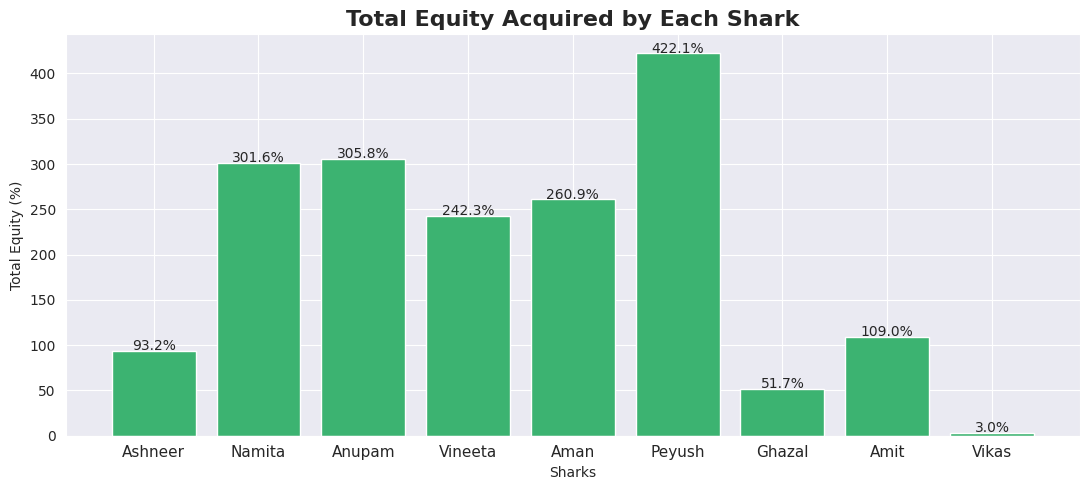

In [95]:
# Visualizing Total Equity Acquired by Each Shark

equity_summary = pd.DataFrame({
    'Name': ['Ashneer', 'Namita', 'Anupam', 'Vineeta', 'Aman',
             'Peyush', 'Ghazal', 'Amit', 'Vikas'],
    'Total Equity': [
        shark_tank['Ashneer Investment Equity'].sum(),
        shark_tank['Namita Investment Equity'].sum(),
        shark_tank['Anupam Investment Equity'].sum(),
        shark_tank['Vineeta Investment Equity'].sum(),
        shark_tank['Aman Investment Equity'].sum(),
        shark_tank['Peyush Investment Equity'].sum(),
        shark_tank['Ghazal Investment Equity'].sum(),
        shark_tank['Amit Investment Equity'].sum(),
        shark_tank['Guest Investment Equity'].sum()
    ]
})

plt.figure(figsize=(11, 5))

bars = plt.bar(
    equity_summary['Name'],
    equity_summary['Total Equity'],
    color='mediumseagreen'
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f'{bar.get_height():.1f}%',
        ha='center',
        fontsize=10
    )

plt.title('Total Equity Acquired by Each Shark', fontsize=16, fontweight='bold')
plt.xlabel('Sharks')
plt.ylabel('Total Equity (%)')
plt.xticks(fontsize=11)

plt.tight_layout()
plt.show()

# Startups That Secured Their Requested Valuation

In [96]:
# Startups That Secured Their Requested Valuation

matched_valuation = (
    shark_tank.loc[
        shark_tank['Valuation Requested'] == shark_tank['Deal Valuation'],
        ['Startup Name', 'Valuation Requested', 'Deal Valuation']
    ]
    .reset_index(drop=True)
)

matched_valuation


,Startup Name,Valuation Requested,Deal Valuation
0,Kavach,50.0,50.0
1,BeyondSnack,2000.0,2000.0
2,Cocofit,0.0,0.0
3,WattTechnovations,0.0,0.0
4,TheSimplySalad,300.0,300.0
5,Janitri,4000.0,4000.0
6,NeoMotion,10000.0,10000.0
7,PadCare,2500.0,2500.0
8,Geeani,1000.0,1000.0
9,MindPeers,5300.0,5300.0


# Insight:
##Several startups were in the pre-revenue stage or had not generated any revenue at the time of their pitch.

In [97]:
# Startups That Were Pre-Revenue at the Time of Pitching

pre_revenue_startups = (
    shark_tank.loc[
        shark_tank['Yearly Revenue'] == 0,
        ['Startup Name']
    ]
    .reset_index(drop=True)
)

print(f" Total Pre-Revenue Startups: {len(pre_revenue_startups)}")

pre_revenue_startups

 Total Pre-Revenue Startups: 13


,Startup Name
0,MotionBreeze
1,GoodGoodPiggy
2,JulaaAutomation
3,Scholify
4,Sabjikothi
5,On2Cook
6,Scintiglo
7,Sayonara
8,PMV
9,CureSee


# Most Frequent Keywords in Startup Names

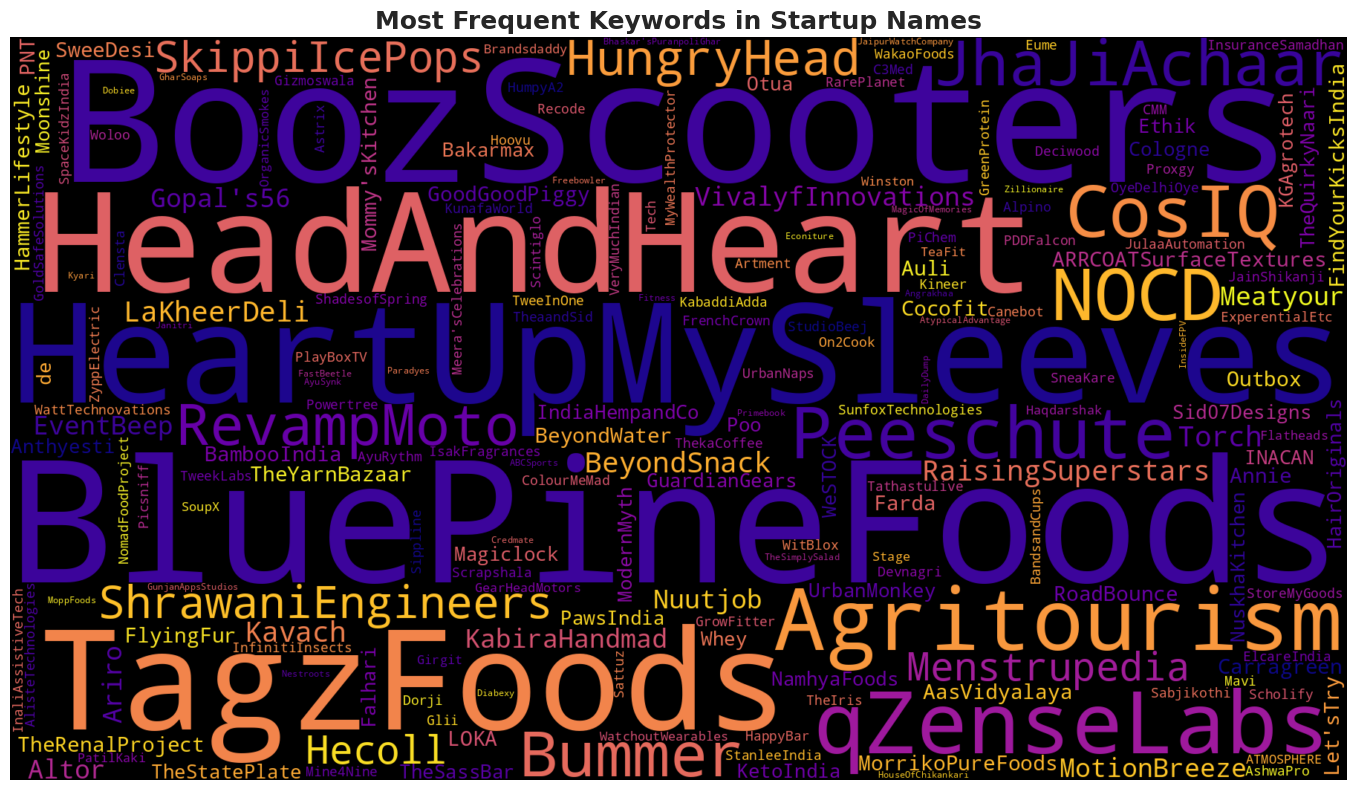

In [98]:
# Creating a Word Cloud from Startup Names
from wordcloud import WordCloud, STOPWORDS
startup_names = " ".join(shark_tank['Startup Name'])

wordcloud = WordCloud(
    width=1800,
    height=1000,
    background_color='black',
    colormap='plasma',
    stopwords=STOPWORDS,
    collocations=False,
    random_state=42
).generate(startup_names)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Keywords in Startup Names', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

Connect With Me

Tajveer Singh

 GitHub: https://github.com/tajveersingh1

 LinkedIn: www.linkedin.com/in/tajveer-singh-133939202

Thank you for visiting this project. Happy Learning!